In [1]:
import pandas as pd 
import numpy as np 
import os 
import cv2
from psychopy import visual, core, event, gui, data, monitors


pygame 2.6.1 (SDL 2.28.4, Python 3.9.6)
Hello from the pygame community. https://www.pygame.org/contribute.html


2026-01-08 12:59:55.744 Python[1215:13246] ApplePersistenceIgnoreState: Existing state will not be touched. New state will be written to /var/folders/hx/_mmjyqq16qz4j0s1w8_drb5c0000gn/T/com.apple.python3.savedState
/Users/olgagulka/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
# pilot 23 guest looks a bit odd (sparse eye data I think)
# pilot 25 has only one seesion so far

1106

In [26]:
#specific for each participant and movie type
folder = "prayer" #adjust
part = "01"  #adjust
participant_id = "pilot_37"  # Adjust per participant

video_name = f"{folder}_part_{part}_NoCal.mp4"  #witness_part_02_NoCal.mp4 #ADJUST
#video_name= f"NO_CAL_GUEST_part{part}.mp4"    
movie_type = f"{folder}_run_{part}" 

start = 2931732.982 # the value from which the movie start as saved in time_log_movies file I record separately   #ADJUST


# File paths

#eye data file can be adjusted to be either all gaze or fixations
eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/{folder}/{participant_id}_{movie_type}/User 0_all_gaze.csv"  #User 0_all_gaze.csv   0_fixations.csv
output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/" 

In [28]:
import pandas as pd
import numpy as np
import os

# ===================== USER INPUTS =====================
eye_data_file = "/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot_37/prayer/pilot_37_prayer_run_01/User 0_all_gaze.csv"

movie_start = 2931732.982  # absolute movie start time (seconds)
tick_hz = 10_000_000       # TIMETICK frequency

output_file = eye_data_file.replace(".csv", "_NaN_padded.csv")
# ======================================================

df = pd.read_csv(eye_data_file)

# Convert TIMETICK to absolute seconds
tick_col = "TIMETICK(f=10000000)"
if tick_col not in df.columns:
    raise ValueError(f"Expected column '{tick_col}' not found in file.")

df["timestamp_abs"] = df[tick_col] / tick_hz

first_eye_time = df["timestamp_abs"].iloc[0]
delay = first_eye_time - movie_start
print(f"Eye tracking started {delay:.3f} seconds after movie start")

# If eye started BEFORE movie, you don't need padding
if delay <= 0:
    print("No NaN padding needed (eye tracking started before movie). Saving unchanged copy.")
    df.to_csv(output_file, index=False)
    print(f"Saved to: {output_file}")
    raise SystemExit

# Estimate sampling interval robustly (median diff, ignoring weird jumps)
diffs = np.diff(df["timestamp_abs"].values)
diffs = diffs[np.isfinite(diffs)]
diffs = diffs[diffs > 0]

if len(diffs) == 0:
    raise ValueError("Could not estimate sampling interval from TIMETICK.")

dt = np.median(diffs)
fs = 1 / dt
print(f"Estimated sampling rate: {fs:.2f} Hz (dt={dt:.6f}s)")

# Number of missing samples to insert before first sample
n_missing = int(np.floor(delay / dt))
print(f"Inserting {n_missing} NaN rows (~{n_missing*dt:.3f} seconds)")

if n_missing <= 0:
    # Delay is tiny; just save unchanged
    df.to_csv(output_file, index=False)
    print(f"Saved to: {output_file}")
    raise SystemExit

# Build timestamps for the missing block (absolute seconds)
nan_timestamps_abs = movie_start + np.arange(n_missing) * dt

# ---- THE FIX: create a nan_block with ALL original columns ----
nan_block = pd.DataFrame({col: np.nan for col in df.columns}, index=np.arange(n_missing))

# Fill key columns
nan_block[tick_col] = (nan_timestamps_abs * tick_hz).astype(np.int64)
nan_block["timestamp_abs"] = nan_timestamps_abs

# Optional: set some metadata columns to something consistent (helps later debugging)
# If these columns exist, copy them from the first row of real data
for col in ["MEDIA_ID", "MEDIA_NAME", "USER"]:
    if col in df.columns:
        nan_block[col] = df[col].iloc[0]

# If CNT exists, create a sensible sequence (CNT is often sample counter)
if "CNT" in df.columns:
    start_cnt = df["CNT"].iloc[0]
    nan_block["CNT"] = np.arange(start_cnt - n_missing, start_cnt)

# Keep exact column order
nan_block = nan_block[df.columns]

# Concatenate NaNs + real data
df_padded = pd.concat([nan_block, df], ignore_index=True)

# Save
df_padded.to_csv(output_file, index=False)
print(f"NaN-padded eye-tracking file saved to:\n{output_file}")


Eye tracking started 3.227 seconds after movie start
Estimated sampling rate: 60.87 Hz (dt=0.016428s)
Inserting 196 NaN rows (~3.220 seconds)
NaN-padded eye-tracking file saved to:
/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot_37/prayer/pilot_37_prayer_run_01/User 0_all_gaze_NaN_padded.csv


In [29]:

#check
filtered_some_data["timestamp"].min() == 0
filtered_some_data["timestamp"].max() ≈ video_duration


SyntaxError: invalid character '≈' (U+2248) (4222830817.py, line 3)

In [ ]:
#I fisnihsed pre prcoesssing pilot 21, now start from 22

## pre processing all upcoming participants - final version of the script
### (Oct, 2025)

In [59]:

" =====   adjusting all the paramaters below ====="

#specific for each participant and movie type
folder = "sprout" #adjust
part = "02"  #adjust
participant_id = "pilot_37"  # Adjust per participant

video_name = f"{folder}_part_{part}_NoCal.mp4"  #witness_part_02_NoCal.mp4 #ADJUST
#video_name= f"NO_CAL_GUEST_part{part}.mp4"    
movie_type = f"{folder}_run_{part}" 

start = 2934083.247 # the value from which the movie start as saved in time_log_movies file I record separately   #ADJUST


# File paths

#eye data file can be adjusted to be either all gaze or fixations
eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/{folder}/{participant_id}_{movie_type}/User 0_all_gaze.csv"  #User 0_all_gaze.csv   0_fixations.csv
output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/" 

"====== end of adjustable parameters ======"


from pymediainfo import MediaInfo
#"/Users/olgagulka/Desktop/IBS/eye_tracking/movies/SPROUT_NATPAC_02.mp4"  # for pilot 01 

video_file = MediaInfo.parse(f"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/{video_name}")    #"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_02_NoCal.mp4"
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        video_duration = duration_ms / 1000
        print(f"Duration: {video_duration:.2f} seconds")



# Load and preprocess eye-tracking data
eye_data = pd.read_csv(eye_data_file)

columns = ["FPOGX", "FPOGY", "TIMETICK(f=10000000)"] #"TIME(2025/03/26 11:06:32.014)    "TIMETICK(f=10000000)"

coord_data = eye_data[columns].copy()





#trim the length of the eye tracking data to the length of the movie

# Convert TIMETICK to seconds


coord_data["timestamp"] = coord_data["TIMETICK(f=10000000)"] / 10000000


# Find index of the closest value in "timestamp"
closest_idx = (coord_data["timestamp"] - start).abs().idxmin()

# Keep only rows from that index onward
coord_data = coord_data.loc[closest_idx:].copy()

# Reset "timestamp" so that the first kept row = 0
coord_data["timestamp"] = coord_data["timestamp"] - coord_data["timestamp"].iloc[0]

#reset the dataframe index to start from 0
coord_data.reset_index(drop=True, inplace=True)

print(coord_data.head())



# Trim to match video duration

coord_data = coord_data[coord_data["timestamp"] <= video_duration]




#counting how many zero or negative values in the dataset
count_negatives_x = (coord_data["FPOGX"] < 0).sum()
count_negatives_y = (coord_data["FPOGY"] < 0).sum()
count_zeros_x = (coord_data["FPOGX"] == 0).sum()
count_zeros_y = (coord_data["FPOGY"] == 0).sum()

#replacing the zero, negative or higher than 1 values with NaN (important for interpolation)
coord_data["FPOGX"] = coord_data["FPOGX"].mask((coord_data["FPOGX"] <= 0) | (coord_data["FPOGX"] > 1), np.nan)
coord_data["FPOGY"] = coord_data["FPOGY"].mask((coord_data["FPOGY"] <= 0) | (coord_data["FPOGY"] > 1), np.nan)


#interpolating the invalid Nan values with the linear function based on the values before and after each missing sample
coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='linear', limit_direction='both')
coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='linear', limit_direction='both')

#interpolating only the internal NaN values, leaving starting and ending NaNs if any
#coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method="linear", limit_area="inside")
#coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method="linear", limit_area="inside")


#Spline way of interpolating the zero values

#coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='spline', order=2, limit_direction='both')
#coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='spline', order=2, limit_direction='both')


#optoionally I can cl1ip the values to be between 0 and 1, in case the interpolation overshoots if there is a sharp jump in eye gaze
#coord_data["FPOGX"] = coord_data["FPOGX"].clip(0, 1)
#coord_data["FPOGY"] = coord_data["FPOGY"].clip(0, 1)


#screen resolution
screen_width = 1024
screen_height = 768  

# Compute pixel coordinates
coord_data["x"] = coord_data["FPOGX"] * screen_width

#coord_data["y"] = coord_data["FPOGY"] * screen_height

coord_data["y"] = (1 - coord_data["FPOGY"]) * screen_height #Ali's suggestion of scaling the y's coordinates


#keep only rows where x and y coordinates are within the screen resolution
#valid_coords = (coord_data["x"] <= screen_width) & (coord_data["y"] <= screen_height) # there seems to be no difference between 


# Apply the filter to the entire DataFrame

#filtered_data = coord_data[valid_coords].copy()
filtered_data = []
filtered_data = coord_data[["x", "y", "timestamp"]]

#checking if the x and y are within the screen resolution
print("x and y coordinates, resepctively maximum value (to see if is within screen resolution", filtered_data["x"].max(), filtered_data["y"].max())
print("x and y coordinates, resepctively minimum value (to see if is within screen resolution:", filtered_data["x"].min(), "," ,filtered_data["y"].min())

# Optionally print confirmation
#print(f"Original data points: {len(coord_data)}")
print(f"Trimmed data points: {len(filtered_data)}")

#double check that there are no neative numbers left
negative_count = (filtered_data["x"] < 0).sum()
negative_count_y = (filtered_data["y"] < 0).sum()
print("Number of negative values in x_coord and y_coord:", negative_count, negative_count_y)

zeros = (filtered_data["x"] == 0).sum()
zeros_y = (filtered_data["x"] == 0).sum()
print("Number of zeros in x_coord", zeros, zeros_y)




filtered_some_data = filtered_data[["timestamp", "x", "y"]].copy()




# save the filtered data to a new CSV file
saved_data_file = os.path.join(os.path.dirname(output_dir),f"{movie_type}_{participant_id}_filtered_eye_data.csv") # fixations or all gaze 
filtered_some_data.to_csv(saved_data_file, index=False)
print(f"Filtered eye-tracking data saved to {saved_data_file}")


Duration: 634.12 seconds
     FPOGX    FPOGY  TIMETICK(f=10000000)  timestamp
0  0.47024  0.54113        29340832503153   0.000000
1  0.47077  0.54186        29340832668818   0.016566
2  0.47079  0.54250        29340832831566   0.032841
3  0.47086  0.54319        29340832995365   0.049221
4  0.47102  0.54265        29340833159324   0.065617
x and y coordinates, resepctively maximum value (to see if is within screen resolution 994.02752 764.98176
x and y coordinates, resepctively minimum value (to see if is within screen resolution: 1.11616 , 3.4636800000000108
Trimmed data points: 38598
Number of negative values in x_coord and y_coord: 0 0
Number of zeros in x_coord 0 0
Filtered eye-tracking data saved to /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_02_pilot_37_filtered_eye_data.csv


In [31]:
filtered_some_data

,timestamp,x,y
0,0.000000,NaN,NaN
1,0.016428,NaN,NaN
2,0.032857,NaN,NaN
3,0.049285,NaN,NaN
4,0.065714,NaN,NaN
...,...,...,...
43179,709.405850,415.20128,674.97728
43180,709.422402,380.89216,696.01408
43181,709.438682,346.58304,717.05088
43182,709.455246,706.37568,690.81600


In [32]:
video_name

'prayer_part_01_NoCal.mp4'

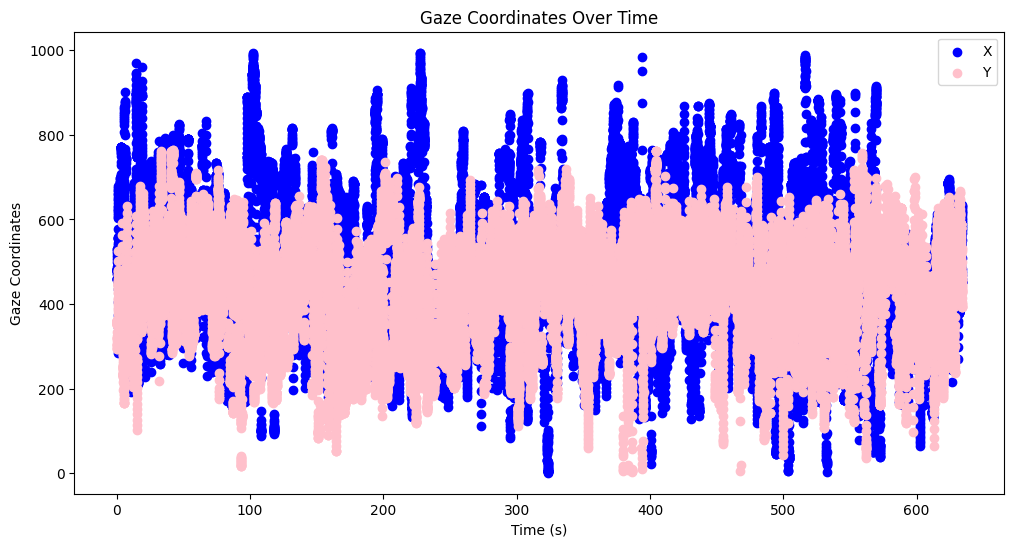

In [60]:
#plotting the gaze points over the time series 
import matplotlib.pyplot as plt
import pandas as pd

x = filtered_some_data["x"]
y = filtered_some_data["y"]
time = filtered_some_data["timestamp"]
plt.figure(figsize=(12, 6))
plt.scatter(time, x, label="xo coordinates", color='blue')
plt.scatter(time, y, label="y coordinates", color='pink')
plt.xlabel("Time (s)")
plt.ylabel("Gaze Coordinates")
plt.title("Gaze Coordinates Over Time")

plt.legend(["X", "Y"])

plt.show()



### merging two files of the eye tracking data together (same movie, run 01 + run 02)

In [51]:
import os
import pandas as pd

def merge_movie_parts(movie_type: str, participant_id: str):
    """
    Merge two parts (run_01 and run_02) of the same movie for a given participant.
    Adds a 'movie_part' column indicating the source (e.g., sprout_run_01 or sprout_run_02).
    
    Parameters
    ----------
    movie_type : str
        The base name of the movie (e.g., 'sprout' or 'prayer').
    participant_id : str
        The participant identifier (e.g., 'pilot_05').
    
    Saves
    -----
    A merged CSV file to:
    /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/merged_parts/{movie_type}/{movie_type}_{participant_id}_merged_eye_data.csv
    """
    
    base_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered"
    part_01 = f"{movie_type}_run_01"
    part_02 = f"{movie_type}_run_02"
    
    dir_01 = os.path.join(base_dir, part_01, f"{part_01}_{participant_id}_filtered_eye_data.csv")
    dir_02 = os.path.join(base_dir, part_02, f"{part_02}_{participant_id}_filtered_eye_data.csv")
    
    if not os.path.exists(dir_01):
        raise FileNotFoundError(f"Missing file: {dir_01}")
    if not os.path.exists(dir_02):
        raise FileNotFoundError(f"Missing file: {dir_02}")
    
    # Load and label data
    data_01 = pd.read_csv(dir_01)
    data_01["movie_part"] = part_01
    
    data_02 = pd.read_csv(dir_02)
    data_02["movie_part"] = part_02
    
    # Concatenate data
    merged_data = pd.concat([data_01, data_02], ignore_index=True)
    
    # Create output directory if not exists
    output_dir = os.path.join(base_dir, "merged_parts", movie_type)
    os.makedirs(output_dir, exist_ok=True)
    
    # Save merged data
    output_path = os.path.join(output_dir, f"{movie_type}_{participant_id}_merged_eye_data.csv")
    merged_data.to_csv(output_path, index=False)
    
    print(f"Merged data with 'movie_part' saved successfully at:\n{output_path}")


In [ ]:
### script for pre processing FIXATION data 



import os
import numpy as np
import pandas as pd
from pymediainfo import MediaInfo

" =====   adjusting all the paramaters below ====="

folder = "sprout"
part = "02"
participant_id = "pilot_37"

video_name = f"{folder}_part_{part}_NoCal.mp4"
movie_type = f"{folder}_run_{part}"

start = 2934083.247  # seconds in TIMETICK/1e7 timebase  # ADJUST

eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/{folder}/{participant_id}_{movie_type}/User 0_fixations.csv"
output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/"

screen_width = 1024
screen_height = 768

"====== end of adjustable parameters ======"


# --- video duration ---
video_path = f"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/{video_name}"
video_info = MediaInfo.parse(video_path)
video_duration = None
for track in video_info.tracks:
    if track.track_type == "General":
        video_duration = track.duration / 1000
        break
if video_duration is None:
    raise RuntimeError("Could not read video duration.")


# --- load fixations ---
df = pd.read_csv(eye_data_file)

# keep only valid fixations
if "FPOGV" in df.columns:
    df = df[df["FPOGV"] == 1].copy()

# absolute time axis from TIMETICK
df["timestamp_abs"] = df["TIMETICK(f=10000000)"] / 10000000

# align to movie start using TIMETICK timebase
closest_idx = (df["timestamp_abs"] - start).abs().idxmin()
df = df.loc[closest_idx:].copy()

df["timestamp"] = df["timestamp_abs"] - df["timestamp_abs"].iloc[0]

# trim to movie duration
df = df[df["timestamp"] <= video_duration].copy()

# drop invalid normalized coords
invalid_xy = (df["FPOGX"] <= 0) | (df["FPOGX"] > 1) | (df["FPOGY"] <= 0) | (df["FPOGY"] > 1)
df = df[~invalid_xy].copy()

# pixel coords (y inverted to match your convention)
df["x"] = df["FPOGX"] * screen_width
df["y"] = (1 - df["FPOGY"]) * screen_height

# duration from FPOGD (per handbook)
if "FPOGD" not in df.columns:
    raise ValueError("Fixations file missing FPOGD (fixation duration).")
df["duration"] = df["FPOGD"].astype(float)

# end timestamp (useful for trial slicing)
df["end_timestamp"] = df["timestamp"] + df["duration"]

# output columns
keep_cols = ["timestamp", "end_timestamp", "duration", "x", "y"]
if "FPOGID" in df.columns: keep_cols.append("FPOGID")
if "VID_FRAME" in df.columns: keep_cols.append("VID_FRAME")
if "MEDIA_NAME" in df.columns: keep_cols.append("MEDIA_NAME")

out = df[keep_cols].copy()
out.reset_index(drop=True, inplace=True)

os.makedirs(output_dir, exist_ok=True)
saved_data_file = os.path.join(output_dir, f"{movie_type}_{participant_id}_filtered_fixations.csv")
out.to_csv(saved_data_file, index=False)
print("Saved:", saved_data_file)
print(out.head())



## getting age and sex information from the demographic file with participants

In [9]:
import numpy as np
import pandas as pd
from datetime import datetime

path = r"/Users/olgagulka/Desktop/IBS/participants_demographics/(NEW) Participant_Data - Sheet1.csv"

# --- read file (handle Korean encodings) ---
for enc in ["utf-8-sig", "cp949", "euc-kr"]:
    try:
        df = pd.read_csv(path, encoding=enc, dtype={"ID": str, "생년월일": str})
        break
    except UnicodeDecodeError:
        continue
else:
    raise UnicodeDecodeError("Could not decode file with utf-8-sig/cp949/euc-kr")

# If your file is actually tab-separated, use this instead:
# df = pd.read_csv(path, encoding="utf-8-sig", sep="\t", dtype={"ID": str, "생년월일": str})

dic = ["00006", "00073", "00082", "00062", "00083", "00054", "00085", "00086", "00081", "00087",
       "00079", "00008", "00069", "00084", "00074", "00071", "00060", "00070", "00052", "00089",
       "00096", "00097", "00103", "00091", "00098", "00051", "00104", "00092", "00129", "00124"]

# --- normalize IDs so "6" matches "00006" etc. ---
df["ID"] = df["ID"].str.strip()
df["ID_5"] = df["ID"].str.zfill(5)
in_dic = df["ID_5"].isin(dic)

# --- count females among dic IDs ---
female_count = ((df["성"].astype(str).str.strip() == "여") & in_dic).sum()

# --- parse birth year from 생년월일 (stored as yymmdd but zeros dropped) ---
s = df["생년월일"].astype(str).str.strip()

# keep only digits, then pad to 6 (so 109 -> 000109, 10615 -> 010615)
s = s.str.replace(r"\D", "", regex=True).str.zfill(6)

yy = pd.to_numeric(s.str[:2], errors="coerce")

current_year = datetime.now().year
current_yy = current_year % 100

# infer century: if yy <= current_yy => 2000+yy else 1900+yy
birth_year = np.where(yy <= current_yy, 2000 + yy, 1900 + yy)
birth_year = pd.Series(birth_year, index=df.index).where(~np.isnan(yy), np.nan)

df["age"] = np.where(in_dic, current_year - birth_year, np.nan)

df_age = df.loc[in_dic, "age"].dropna()
mean_age = df_age.mean()
std_age = df_age.std(ddof=1)

print("N (dic IDs):", in_dic.sum())
print("Number of females:", int(female_count))
print("Mean age:", float(mean_age))
print("SD age:", float(std_age))


N (dic IDs): 30
Number of females: 23
Mean age: 24.0
SD age: 2.034190510862431


np.int64(23)

### Pre-processing the data from memory experiment. The initial version, used for pilot 01 - pilot 03)
##### for GUEST movie there is a black portion on the left and right side (89 pixels in NatPAC movies but it may be different in our exp)
##### the resolution of the movies is 1600 x 1000 but for GUEST it is 1778 x 1000
#####  ther resolution of the monitor is 1024 x 768


In [1]:


# File paths
#video_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/movies/NO_CAL_GUEST_part01.mp4"
#eye_data_file = "/Users/olga.gulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot01/sprout_run2_pilot01/pilot_01_all_gaze.csv" #for my airmac
eye_data_file = "/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot_03/sprout/pilot_03_sprout_run_02/User 0_all_gaze.csv"  
output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/" 
#heatmap_output_dir = "/Users/olga.gulka/Desktop/IBS/eye_tracking/heatmaps"
participant_id = "pilot_03"  # Adjust per participant
movie_type = "sprout_run_02" # Adjust per movie type

# Create output directory if it doesn't exist
#os.makedirs(heatmap_output_dir, exist_ok=True)

# Load and preprocess eye-tracking data
eye_data = pd.read_csv(eye_data_file)

columns = ["FPOGX", "FPOGY", "TIMETICK(f=10000000)"] #"TIME(2025/03/26 11:06:32.014)    "TIMETICK(f=10000000)"

coord_data = eye_data[columns].copy()

#screen resolution

screen_width = 1024
screen_height = 768  

#trim the length of the eye tracking data to the length of the movie

coord_data = []


#replacing the zero, negative or higher than 1 values with NaN (important for interpolation)

coord_data["FPOGX"] = coord_data["FPOGX"].mask((coord_data["FPOGX"] <= 0) | (coord_data["FPOGX"] > 1), np.nan)
coord_data["FPOGY"] = coord_data["FPOGY"].mask((coord_data["FPOGY"] <= 0) | (coord_data["FPOGY"] > 1), np.nan)



#interpolating the 0 values with the linear function
coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='linear', limit_direction='both')
coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='linear', limit_direction='both')

#Spline way of interpolating the zero values

#coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='spline', order=2, limit_direction='both')
#coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='spline', order=2, limit_direction='both')


#optoionally I can cl1ip the values to be between 0 and 1, in case the interpolation overshoots if there is a sharp jump in eye gaze
#coord_data["FPOGX"] = coord_data["FPOGX"].clip(0, 1)
#coord_data["FPOGY"] = coord_data["FPOGY"].clip(0, 1)

# Compute pixel coordinates
coord_data["x"] = coord_data["FPOGX"] * screen_width

#coord_data["y"] = coord_data["FPOGY"] * screen_height

coord_data["y"] = (1 - coord_data["FPOGY"]) * screen_height #Ali's suggestion of scaling the y's coordinates


#keep only rows where x and y coordinates are within the screen resolution
valid_coords = (coord_data["x"] <= screen_width) & (coord_data["y"] <= screen_height)

#I think I should crop the length (only from the end of the file) of the data to match the length of the video
#video = cv2.VideoCapture(video_file)
#video_length = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
#video.release()
#coord_data = coord_data.iloc[:video_length]




# Apply the filter to the entire DataFrame
filtered_data = coord_data[valid_coords].copy()


#double check that all zeros and negative number are removed
negative_count = (filtered_data["x"] < 0).sum()
negative_count_y = (filtered_data["y"] < 0).sum()
print("Number of negative values in x_coord and y_coord:", negative_count, negative_count_y)

zeros = (filtered_data["x"] == 0).sum()
zeros_y = (filtered_data["x"] == 0).sum()
print("Number of zeros in x_coord", zeros, zeros_y)

#filtered_data["timestamp"] = filtered_data["TIME(2025/03/26 11:06:32.014)"]
filtered_data['timeick'] = filtered_data["TIMETICK(f=10000000)"]/ 10000000

filtered_data["timestamp"] = filtered_data["timeick"] - filtered_data["timeick"].iloc[0]

filtered_some_data = filtered_data[[ "timestamp", "x", "y"]].copy()




# save the filtered data to a new CSV file
saved_data_file = os.path.join(os.path.dirname(output_dir),f"{movie_type}_{participant_id}_filtered_eye_data.csv")
filtered_some_data.to_csv(saved_data_file, index=False)
print(f"Filtered eye-tracking data saved to {saved_data_file}")

NameError: name 'pd' is not defined

## syncing the beginning of the movie (value got from the psychopy script) with the gazepoint recorded timestamps

#### I modified the psychopy script and now there are headers for each column (but for pilot 05,06 there are NO)

In [2]:


from pymediainfo import MediaInfo

video_file = MediaInfo.parse("/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_01_NoCal.mp4")
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        duration_s = duration_ms / 1000
        print(f"Duration: {duration_s:.2f} seconds")

        

Duration: 503.87 seconds


In [ ]:
#checking how many frames and how long is the video 
video_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/prayer_part_02_NoCal.mp4" # Change this to your video file path

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video file.")
else:
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    

    print(f"Total frames: {total_frames}")
    print(f"FPS: {fps}")
    

cap.release()

Total frames: 18695
FPS: 23.975653714356067


In [30]:
video_file = MediaInfo.parse("/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/prayer_part_02_NoCal.mp4")    #"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_02_NoCal.mp4"
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        video_duration = duration_ms / 1000
        print(f"Duration: {video_duration:.2f} seconds")

Duration: 779.60 seconds


In [ ]:
#sprout  part 02
#FPS: 23.976023976023978
#Duration (seconds): 634.80

#prayer part 01
#FPS: 23.97354953571343
#Duration (seconds): 709.47 

#prayer part 02
# duration 779.60 sec


In [24]:

eye_data["timestamp"] 

0          0.000000
1          0.016262
2          0.032594
3          0.049225
4          0.065810
            ...    
36824    605.291194
36825    605.307553
36826    605.324154
36827    605.340460
36828    605.356959
Name: timestamp, Length: 36829, dtype: float64

In [36]:
folder = "prayer"
participant_id = "pilot_03"  # Adjust per participant
movie_type = "prayer_run_01" # Adjust per movie type


# File paths
#video_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/movies/NO_CAL_GUEST_part01.mp4"
#eye_data_file = "/Users/olga.gulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot01/sprout_run2_pilot01/pilot_01_all_gaze.csv" #for my airmac
eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/{folder}/{participant_id}_{movie_type}/User 0_all_gaze.csv"  #User 0_all_gaze.csv
output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/" 

eye_data = pd.read_csv(eye_data_file)

In [37]:
eye_data

,MEDIA_ID,MEDIA_NAME,CNT,TIME(2025/04/15 12:35:55.149),TIMETICK(f=10000000),FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,...,DIALV,TTL6,TTLV,PIXS,PIXV,AOI,SACCADE_MAG,SACCADE_DIR,VID_FRAME,Unnamed: 47
0,0,NewMedia0,0,0.00000,3172120970610,0.71274,0.69825,0.00000,0.00000,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
1,0,NewMedia0,1,0.01624,3172121133154,0.76683,0.72939,0.00000,0.00000,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
2,0,NewMedia0,2,0.03247,3172121295151,0.54265,0.77339,0.00000,0.00000,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
3,0,NewMedia0,3,0.04883,3172121459258,0.38819,0.79978,0.00000,0.00000,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,1,NaN
4,0,NewMedia0,4,0.06531,3172121623957,0.15900,0.84084,0.00000,0.00000,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49490,0,NewMedia0,49490,813.27502,3180253720397,0.19990,1.95561,813.20935,0.06567,2249,...,0,1,0,0.0,0,NaN,0.00000,0.00000,19499,NaN
49491,0,NewMedia0,49491,813.29163,3180253887390,0.19990,1.95561,813.20935,0.08228,2249,...,0,1,0,0.0,0,NaN,0.00000,0.00000,19499,NaN
49492,0,NewMedia0,49492,813.30774,3180254047824,0.18634,1.96069,813.20935,0.09839,2249,...,0,1,0,0.0,0,NaN,0.00000,0.00000,19499,NaN
49493,0,NewMedia0,49493,813.32410,3180254212844,0.17730,1.96408,813.20935,0.11475,2249,...,0,1,0,0.0,0,NaN,584.07007,271.37128,19500,NaN


In [10]:
from pymediainfo import MediaInfo
video_name = "prayer_part_01_NoCal.mp4"

video_file = MediaInfo.parse(f"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/{video_name}")    #"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_02_NoCal.mp4"
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        video_duration = duration_ms / 1000
        print(f"Duration: {video_duration:.2f} seconds")

Duration: 709.47 seconds


In [ ]:
806.96 - 64 =

## the script version (May) for pre-processing eye gaze
## this is for pilot 05 and 06 


In [ ]:
####### I want to trim the data to the length of the video 

#specific for each participant and movie type
folder = "witness"
participant_id = "pilot_06"  # Adjust per participant
movie_type = "witness_run_01" # Adjust per movie type
video_name = "witness_part_01_NoCal.mp4"


# File paths
#video_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/movies/NO_CAL_GUEST_part01.mp4"
#eye_data_file = "/Users/olga.gulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot01/sprout_run2_pilot01/pilot_01_all_gaze.csv" #for my airmac
eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/{folder}/{participant_id}_{movie_type}/User 1_all_gaze.csv"  #User 0_all_gaze.csv
output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/" 
#heatmap_output_dir = "/Users/olga.gulka/Desktop/IBS/eye_tracking/heatmaps"



# load the video and get its duration in seconds
#video_file = "/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/prayer_part_01_NoCal.mp4"
#cap = cv2.VideoCapture(video_file)
#fps = int(cap.get(cv2.CAP_PROP_FPS))
#frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#video_duration = frame_count / fps
#cap.release()
#print(f"Video duration: {video_duration:.2f} seconds")


from pymediainfo import MediaInfo
#"/Users/olgagulka/Desktop/IBS/eye_tracking/movies/SPROUT_NATPAC_02.mp4"  # for pilot 01 

video_file = MediaInfo.parse(f"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/{video_name}")    #"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_02_NoCal.mp4"
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        video_duration = duration_ms / 1000
        print(f"Duration: {video_duration:.2f} seconds")



# Load and preprocess eye-tracking data
eye_data = pd.read_csv(eye_data_file)

columns = ["FPOGX", "FPOGY", "TIMETICK(f=10000000)"] #"TIME(2025/03/26 11:06:32.014)    "TIMETICK(f=10000000)"

coord_data = eye_data[columns].copy()





#trim the length of the eye tracking data to the length of the movie

# Convert TIMETICK to seconds
coord_data["timeick"] = coord_data["TIMETICK(f=10000000)"] / 10000000
coord_data["timestamp"] = coord_data["timeick"] - coord_data["timeick"].iloc[0]

#trim the beginning of the eye trakcing timestamp which include the calibrtion from natpac - only pilot_01 to pilot_03 (including)
#for sprout run01: pilot_03 1min 4sec to remove 
#for sprout run 02: pilot_03 40sec to remove
#for witness pilot 04 run01 it starts from 1min 20sec and for run 02 it starts from 50sec

#coord_data= coord_data[coord_data["timestamp"] > 50].reset_index(drop=True) #deleting frist 40 seconds as for pilot 01 and pilot 03, I played the "calbration" part of the video which is from natpac. 
#coord_data["timestamp"] -= coord_data["timestamp"].iloc[0]   #shifting the rest of the timestamps to start from 0

# Trim to match video duration

coord_data = coord_data[coord_data["timestamp"] <= video_duration]




#counting how many zero or negative values in the dataset
count_negatives_x = (coord_data["FPOGX"] < 0).sum()
count_negatives_y = (coord_data["FPOGY"] < 0).sum()
count_zeros_x = (coord_data["FPOGX"] == 0).sum()
count_zeros_y = (coord_data["FPOGY"] == 0).sum()

#replacing the zero, negative or higher than 1 values with NaN (important for interpolation)
coord_data["FPOGX"] = coord_data["FPOGX"].mask((coord_data["FPOGX"] <= 0) | (coord_data["FPOGX"] > 1), np.nan)
coord_data["FPOGY"] = coord_data["FPOGY"].mask((coord_data["FPOGY"] <= 0) | (coord_data["FPOGY"] > 1), np.nan)


#interpolating the invalid Nan values with the linear function based on the values before and after each missing sample
coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='linear', limit_direction='both')
coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='linear', limit_direction='both')

#Spline way of interpolating the zero values

#coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='spline', order=2, limit_direction='both')
#coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='spline', order=2, limit_direction='both')


#optoionally I can cl1ip the values to be between 0 and 1, in case the interpolation overshoots if there is a sharp jump in eye gaze
#coord_data["FPOGX"] = coord_data["FPOGX"].clip(0, 1)
#coord_data["FPOGY"] = coord_data["FPOGY"].clip(0, 1)


#screen resolution
screen_width = 1024
screen_height = 768  

# Compute pixel coordinates
coord_data["x"] = coord_data["FPOGX"] * screen_width

#coord_data["y"] = coord_data["FPOGY"] * screen_height

coord_data["y"] = (1 - coord_data["FPOGY"]) * screen_height #Ali's suggestion of scaling the y's coordinates


#keep only rows where x and y coordinates are within the screen resolution
#valid_coords = (coord_data["x"] <= screen_width) & (coord_data["y"] <= screen_height) # there seems to be no difference between 


# Apply the filter to the entire DataFrame

#filtered_data = coord_data[valid_coords].copy()
filtered_data = []
filtered_data = coord_data[["x", "y", "timestamp"]]

#checking if the x and y are within the screen resolution
print("x and y coordinates, resepctively maximum value (to see if is within screen resolution", filtered_data["x"].max(), filtered_data["y"].max())
print("x and y coordinates, resepctively minimum value (to see if is within screen resolution:", filtered_data["x"].min(), "," ,filtered_data["y"].min())

# Optionally print confirmation
#print(f"Original data points: {len(coord_data)}")
print(f"Trimmed data points: {len(filtered_data)}")

#double check that there are no neative numbers left
negative_count = (filtered_data["x"] < 0).sum()
negative_count_y = (filtered_data["y"] < 0).sum()
print("Number of negative values in x_coord and y_coord:", negative_count, negative_count_y)

zeros = (filtered_data["x"] == 0).sum()
zeros_y = (filtered_data["x"] == 0).sum()
print("Number of zeros in x_coord", zeros, zeros_y)




filtered_some_data = filtered_data[["timestamp", "x", "y"]].copy()




# save the filtered data to a new CSV file
saved_data_file = os.path.join(os.path.dirname(output_dir),f"{movie_type}_{participant_id}_filtered_eye_data.csv")
filtered_some_data.to_csv(saved_data_file, index=False)
print(f"Filtered eye-tracking data saved to {saved_data_file}")

Duration: 864.87 seconds
x and y coordinates, resepctively maximum value (to see if is within screen resolution 999.64928 765.0432
x and y coordinates, resepctively minimum value (to see if is within screen resolution: 2.63168 , 0.3148800000000165
Trimmed data points: 52645
Number of negative values in x_coord and y_coord: 0 0
Number of zeros in x_coord 0 0
Filtered eye-tracking data saved to /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/witness_run_01_pilot_06_filtered_eye_data.csv


In [93]:

print("Total number of zeros, higher than one and negatives in the data (before scaling to the screen size):", count_zeros_y + count_zeros_x + count_negatives_y + count_negatives_x)



Total number of zeros, higher than one and negatives in the data (before scaling to the screen size): 27172


In [102]:
filtered_data

,x,y,timestamp
0,267.22304,422.83776,0.000000
1,283.41248,408.36096,0.016342
2,297.34912,395.92704,0.032795
3,309.08416,382.13376,0.049230
4,319.09888,369.60000,0.065631
...,...,...,...
47625,616.92928,101.82400,782.407659
47626,607.52896,102.10176,782.424220
47627,590.20288,102.37952,782.440672
47628,587.42784,102.65728,782.456989


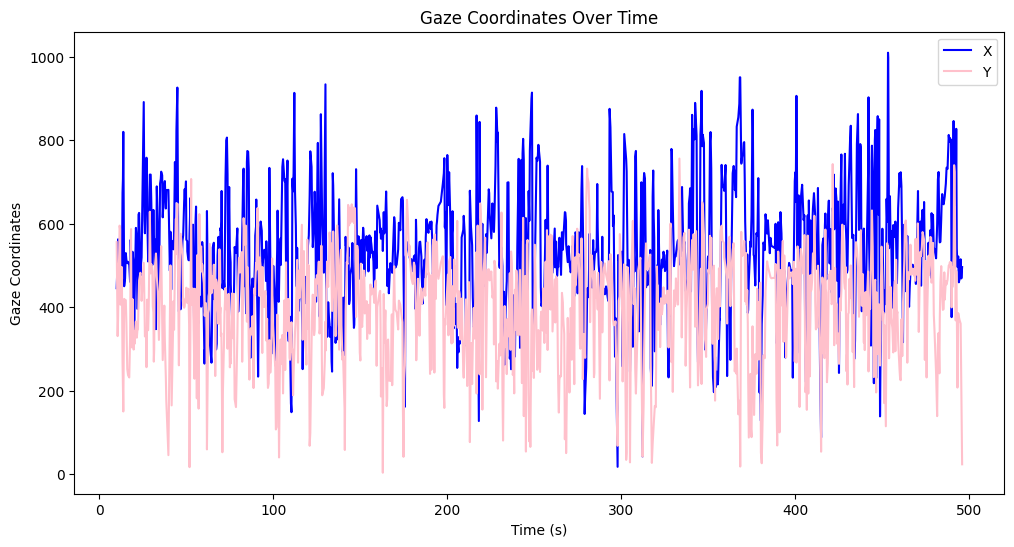

In [169]:
#plotting the gaze points over the time series 
import matplotlib.pyplot as plt


x = filtered_some_data["x"]
y = filtered_some_data["y"]
time = filtered_some_data["timestamp"]
plt.figure(figsize=(12, 6))
plt.plot(time, x, label="xo coordinates", color='blue')
plt.plot(time, y, label="y coordinates", color='pink')
plt.xlabel("Time (s)")
plt.ylabel("Gaze Coordinates")
plt.title("Gaze Coordinates Over Time")
plt.legend(["X", "Y"])
plt.show()


In [17]:
time = df["TIMETICK(f=10000000)"]/ 10000000

In [33]:
start = 656266.759

## script for all upcoming participants

In [ ]:
####### I want to trim the data to the length of the video 

#specific for each participant and movie type
folder = "guest"
participant_id = "pilot_07"  # Adjust per participant
movie_type = "guest_run_02" # Adjust per movie type
video_name = "NO_CAL_GUEST_part02.mp4" #NO_CAL_GUEST_part01.mp4    #witness_part_02_NoCal.mp4
start = 750493.835 # the value from which the movie start as saved in time_log_movies file I record separately 


# File paths


eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/{folder}/{participant_id}_{movie_type}/User 0_all_gaze.csv"  #User 0_all_gaze.csv   0_fixations.csv
output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/" 




from pymediainfo import MediaInfo
#"/Users/olgagulka/Desktop/IBS/eye_tracking/movies/SPROUT_NATPAC_02.mp4"  # for pilot 01 

video_file = MediaInfo.parse(f"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/{video_name}")    #"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_02_NoCal.mp4"
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        video_duration = duration_ms / 1000
        print(f"Duration: {video_duration:.2f} seconds")



# Load and preprocess eye-tracking data
eye_data = pd.read_csv(eye_data_file)

columns = ["FPOGX", "FPOGY", "TIMETICK(f=10000000)"] #"TIME(2025/03/26 11:06:32.014)    "TIMETICK(f=10000000)"

coord_data = eye_data[columns].copy()





#trim the length of the eye tracking data to the length of the movie

# Convert TIMETICK to seconds


coord_data["timestamp"] = coord_data["TIMETICK(f=10000000)"] / 10000000


# Find index of the closest value in "timestamp"
closest_idx = (coord_data["timestamp"] - start).abs().idxmin()

# Keep only rows from that index onward
coord_data = coord_data.loc[closest_idx:].copy()

# Reset "timestamp" so that the first kept row = 0
coord_data["timestamp"] = coord_data["timestamp"] - coord_data["timestamp"].iloc[0]

#reset the dataframe index to start from 0
coord_data.reset_index(drop=True, inplace=True)

print(coord_data.head())



# Trim to match video duration

coord_data = coord_data[coord_data["timestamp"] <= video_duration]




#counting how many zero or negative values in the dataset
count_negatives_x = (coord_data["FPOGX"] < 0).sum()
count_negatives_y = (coord_data["FPOGY"] < 0).sum()
count_zeros_x = (coord_data["FPOGX"] == 0).sum()
count_zeros_y = (coord_data["FPOGY"] == 0).sum()

#replacing the zero, negative or higher than 1 values with NaN (important for interpolation)
coord_data["FPOGX"] = coord_data["FPOGX"].mask((coord_data["FPOGX"] <= 0) | (coord_data["FPOGX"] > 1), np.nan)
coord_data["FPOGY"] = coord_data["FPOGY"].mask((coord_data["FPOGY"] <= 0) | (coord_data["FPOGY"] > 1), np.nan)


#interpolating the invalid Nan values with the linear function based on the values before and after each missing sample
coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='linear', limit_direction='both')
coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='linear', limit_direction='both')

#Spline way of interpolating the zero values

#coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='spline', order=2, limit_direction='both')
#coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='spline', order=2, limit_direction='both')


#optoionally I can cl1ip the values to be between 0 and 1, in case the interpolation overshoots if there is a sharp jump in eye gaze
#coord_data["FPOGX"] = coord_data["FPOGX"].clip(0, 1)
#coord_data["FPOGY"] = coord_data["FPOGY"].clip(0, 1)


#screen resolution
screen_width = 1024
screen_height = 768  

# Compute pixel coordinates
coord_data["x"] = coord_data["FPOGX"] * screen_width

#coord_data["y"] = coord_data["FPOGY"] * screen_height

coord_data["y"] = (1 - coord_data["FPOGY"]) * screen_height #Ali's suggestion of scaling the y's coordinates


#keep only rows where x and y coordinates are within the screen resolution
#valid_coords = (coord_data["x"] <= screen_width) & (coord_data["y"] <= screen_height) # there seems to be no difference between 


# Apply the filter to the entire DataFrame

#filtered_data = coord_data[valid_coords].copy()
filtered_data = []
filtered_data = coord_data[["x", "y", "timestamp"]]

#checking if the x and y are within the screen resolution
print("x and y coordinates, resepctively maximum value (to see if is within screen resolution", filtered_data["x"].max(), filtered_data["y"].max())
print("x and y coordinates, resepctively minimum value (to see if is within screen resolution:", filtered_data["x"].min(), "," ,filtered_data["y"].min())

# Optionally print confirmation
#print(f"Original data points: {len(coord_data)}")
print(f"Trimmed data points: {len(filtered_data)}")

#double check that there are no neative numbers left
negative_count = (filtered_data["x"] < 0).sum()
negative_count_y = (filtered_data["y"] < 0).sum()
print("Number of negative values in x_coord and y_coord:", negative_count, negative_count_y)

zeros = (filtered_data["x"] == 0).sum()
zeros_y = (filtered_data["x"] == 0).sum()
print("Number of zeros in x_coord", zeros, zeros_y)




filtered_some_data = filtered_data[["timestamp", "x", "y"]].copy()




# save the filtered data to a new CSV file
saved_data_file = os.path.join(os.path.dirname(output_dir),f"{movie_type}_{participant_id}_filtered_eye_data.csv") # fixations or all gaze 
filtered_some_data.to_csv(saved_data_file, index=False)
print(f"Filtered eye-tracking data saved to {saved_data_file}")


Duration: 496.30 seconds
     FPOGX    FPOGY  TIMETICK(f=10000000)  timestamp
0  0.48318  0.38539         7504938300461   0.000000
1  0.50151  0.36538         7504938464026   0.016356
2  0.51635  0.35900         7504938629610   0.032915
3  0.52575  0.36082         7504938797315   0.049685
4  0.53411  0.35715         7504938955024   0.065456
x and y coordinates, resepctively maximum value (to see if is within screen resolution 957.71648 767.66976
x and y coordinates, resepctively minimum value (to see if is within screen resolution: 79.9744 , 0.09983999999997195
Trimmed data points: 30209
Number of negative values in x_coord and y_coord: 0 0
Number of zeros in x_coord 0 0
Filtered eye-tracking data saved to /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/guest_run_02_pilot_07_filtered_eye_data.csv


: 

In [71]:
coord_data

,FPOGX,FPOGY,TIMETICK(f=10000000),timestamp,x,y
0,0.51640,0.37812,6569115956914,0.000000,528.79360,477.60384
1,0.58634,0.37238,6569120392848,0.443593,600.41216,482.01216
2,0.56526,0.34248,6569123678151,0.772124,578.82624,504.97536
3,0.57433,0.34568,6569128935562,1.297865,588.11392,502.51776
4,0.48144,0.30090,6569131727903,1.577099,492.99456,536.90880
...,...,...,...,...,...,...
1582,0.43116,0.30574,6575438134876,632.217796,441.50784,533.19168
1583,0.44020,0.28468,6575442081357,632.612444,450.76480,549.36576
1584,0.51987,0.31914,6575446185343,633.022843,532.34688,522.90048
1585,0.51901,0.29542,6575450126298,633.416938,531.46624,541.11744


In [ ]:
#FOR THE DATA I RECORDED OF MYSELF and MINA


from datetime import datetime


# File paths
#video_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/movies/NO_CAL_GUEST_part01.mp4"
#eye_data_file = "/Users/olga.gulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot01/sprout_run2_pilot01/pilot_01_all_gaze.csv" #for my airmac
#eye_data_file = "/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot_testing/sprout/pilot_testing_sprout_run_02/User 0_fixations.csv"  #User 0_all_gaze.csv  
output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/" 

eye_data_file = "/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot_testing/testing_mina/result/User 0_all_gaze.csv"
#heatmap_output_dir = "/Users/olga.gulka/Desktop/IBS/eye_tracking/heatmaps"
participant_id = "pilot_mina"  # Adjust per participant
movie_type = "sprout_run_02" # Adjust per movie type


#video_file = "/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/prayer_part_01_NoCal.mp4"
#cap = cv2.VideoCapture(video_file)
#fps = int(cap.get(cv2.CAP_PROP_FPS))
#frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#video_duration = frame_count / fps
#cap.release()
#print(f"Video duration: {video_duration:.2f} seconds")
#video_duration_01 = 709

#more accurate way of getting the video duration
from pymediainfo import MediaInfo

video_file = MediaInfo.parse("/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_02_NoCal.mp4")
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        video_duration = duration_ms / 1000
        print(f"Duration: {video_duration:.2f} seconds")

# Load and preprocess eye-tracking data
eye_data = pd.read_csv(eye_data_file)

columns = ["FPOGX", "FPOGY", "TIMETICK(f=10000000)"] #"TIME(2025/03/26 11:06:32.014)    "TIMETICK(f=10000000)"

coord_data = eye_data[columns].copy()


#trimmnng the intial part of the eye tracking data to match the start of the movie

## contuning with the conversion of datetime to time ticks (here is specfic for pilot 05 sprout part 2)


# Given values
#eye_tracker_datetime =   #pilot_05  prayer_run_01 : "2025/05/30 10:05:41.056"               #for pilot 05 sprout_run_02: "2025/05/30 10:50:52.875" 
#eye_tracker_tick_start =              #pilot_05  prayer_run_01 : 6941280752244               #for pilot 05 sprout_run_02: 6968398866220  
#movie_start_datetime =      #pilot_05  prayer_run_01 : "2025-05-30 10:06:18.998"                 #for pilot 05 sprout_run_02: "2025-05-30 10:51:11.010"
tick_frequency = 10_000_000

                               #for pilot 06 sprout_run_02: "2025/06/04 10:03:00.170" 
                                 #for pilot 06  sprout_run_02: 11259631341375  
movie_start_tick = 5008872333259  #mina closest to the start tick: 5008872333259   #technically I can delete and keep only      1752113745099 (or even delete 099?)                


# 1. Filter data to only include samples at or after the movie started

# 1. Filter rows at or after movie start

# 1. Filter rows at or after the movie start
coord_data = coord_data[coord_data["TIMETICK(f=10000000)"] >= movie_start_tick].copy()

# 2. Convert TIMETICK to seconds
coord_data["time_sec"] = coord_data["TIMETICK(f=10000000)"] / 10_000_000

# 3. Normalize time so movie starts at 0
coord_data["timestamp"] = coord_data["time_sec"] - (movie_start_tick / 10_000_000)



# Trim to match video duration

coord_data = coord_data[coord_data["timestamp"] <= video_duration]



#replacing the zero, negative or higher than 1 values with NaN (important for interpolation)

coord_data["FPOGX"] = coord_data["FPOGX"].mask((coord_data["FPOGX"] <= 0) | (coord_data["FPOGX"] > 1), np.nan)
coord_data["FPOGY"] = coord_data["FPOGY"].mask((coord_data["FPOGY"] <= 0) | (coord_data["FPOGY"] > 1), np.nan)


#interpolating the 0 values with the linear function
coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='linear', limit_direction='both')
coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='linear', limit_direction='both')


#screen resolution
screen_width = 1024
screen_height = 768  

# Compute pixel coordinates
coord_data["x"] = coord_data["FPOGX"] * screen_width

#coord_data["y"] = coord_data["FPOGY"] * screen_height

coord_data["y"] = (1 - coord_data["FPOGY"]) * screen_height #Ali's suggestion of scaling the y's coordinates

#keep only rows where x and y coordinates are within the screen resolution
#valid_coords = (coord_data["x"] <= screen_width) & (coord_data["y"] <= screen_height) # there seems to be no difference between 


# Apply the filter to the entire DataFrame


#filtered_data = coord_data[valid_coords].copy()
filtered_data = []
filtered_data = coord_data[["x", "y", "timestamp"]]

#checking if the x and y are within the screen resolution
print("x and y coordinates, resepctively maximum value (to see if is within screen resolution", filtered_data["x"].max(), filtered_data["y"].max())
print("x and y coordinates, resepctively minimum value (to see if is within screen resolution:", filtered_data["x"].min(), "," ,filtered_data["y"].min())

#lengt of the data
print("Length of the data:", len(filtered_data))

#double check that there are no neative numbers left
negative_count = (filtered_data["x"] < 0).sum()
negative_count_y = (filtered_data["y"] < 0).sum()
print("Number of negative values in x_coord and y_coord:", negative_count, negative_count_y)

zeros = (filtered_data["x"] == 0).sum()
zeros_y = (filtered_data["x"] == 0).sum()
print("Number of zeros in x_coord", zeros, zeros_y)




filtered_some_data = filtered_data[["timestamp", "x", "y"]].copy()




# save the filtered data to a new CSV file
saved_data_file = os.path.join(os.path.dirname(output_dir),f"{movie_type}_{participant_id}_filtered_eye_data.csv")
filtered_some_data.to_csv(saved_data_file, index=False)
print(f"Filtered eye-tracking data saved to {saved_data_file}")

Duration: 634.12 seconds
x and y coordinates, resepctively maximum value (to see if is within screen resolution 1019.0848 743.55456
x and y coordinates, resepctively minimum value (to see if is within screen resolution: 38.89152 , 3.916799999999995
Length of the data: 38599
Number of negative values in x_coord and y_coord: 0 0
Number of zeros in x_coord 0 0
Filtered eye-tracking data saved to /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_02_pilot_mina_filtered_eye_data.csv


In [357]:
filtered_some_data["timestamp"]

1619       0.000000
1620       0.016621
1621       0.032946
1622       0.049257
1623       0.065660
            ...    
40213    634.041427
40214    634.057681
40215    634.074041
40216    634.090646
40217    634.107132
Name: timestamp, Length: 38599, dtype: float64

In [353]:
coord_data["timestamp"] = coord_data["TIMETICK(f=10000000)"] / 10000000

In [354]:
coord_data["timestamp"] 

0        500860.635759
1        500860.652205
2        500860.668323
3        500860.684962
4        500860.701254
             ...      
41258    501538.442526
41259    501538.458726
41260    501538.475259
41261    501538.491658
41262    501538.508007
Name: timestamp, Length: 41263, dtype: float64

In [330]:
eye_data_file = "/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot_testing/testing_mina/result/User 0_all_gaze.csv"
eye_data= pd.read_csv(eye_data_file)

columns = ["FPOGX", "FPOGY", "TIMETICK(f=10000000)"] #"TIME(2025/03/26 11:06:32.014)    "TIMETICK(f=10000000)"

coord_data = eye_data[columns].copy()
coord_data["FPOGX"] = coord_data["FPOGX"].mask((coord_data["FPOGX"] <= 0) | (coord_data["FPOGX"] > 1), np.nan)
coord_data["FPOGY"] = coord_data["FPOGY"].mask((coord_data["FPOGY"] <= 0) | (coord_data["FPOGY"] > 1), np.nan)


#interpolating the 0 values with the linear function
coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='linear', limit_direction='both')
coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='linear', limit_direction='both')


#screen resolution
screen_width = 1024
screen_height = 768  

# Compute pixel coordinates
coord_data["x"] = coord_data["FPOGX"] * screen_width

#coord_data["y"] = coord_data["FPOGY"] * screen_height

coord_data["y"] = (1 - coord_data["FPOGY"]) * screen_height


In [331]:
coord_data

,FPOGX,FPOGY,TIMETICK(f=10000000),x,y
0,0.40683,0.52016,5008606357586,416.59392,368.51712
1,0.40679,0.51636,5008606522048,416.55296,371.43552
2,0.40684,0.51406,5008606683230,416.60416,373.20192
3,0.40665,0.51304,5008606849621,416.40960,373.98528
4,0.40528,0.51410,5008607012536,415.00672,373.17120
...,...,...,...,...,...
41258,0.41041,0.79822,5015384425263,420.25984,154.96704
41259,0.41041,0.79822,5015384587264,420.25984,154.96704
41260,0.41041,0.79822,5015384752588,420.25984,154.96704
41261,0.41041,0.79822,5015384916579,420.25984,154.96704


In [348]:
import numpy as np

# Assume coord_data["timestamp"] contains gaze timestamps in seconds
# And movie_start is also in seconds
movie_start = 500887.236 *10000000
#coord_data["timestamp"] = round(coord_data["timestamp"],3)
#convert to numpy array
#coord_data["timestamp"] = np.array(coord_data["timestamp"])

time_diffs = np.abs(coord_data["TIMETICK(f=10000000)"] - movie_start)

# Get the index of the minimum difference
closest_index = time_diffs.idxmin()

# Retrieve the closest timestamp and corresponding row
closest_row = coord_data.loc[closest_index]
closest_timestamp = coord_data.loc[closest_index, "TIMETICK(f=10000000)"]

print(f"Closest timestamp to movie start: {closest_timestamp}")
print("Corresponding row in gaze data:")
print(closest_row)




#print(f"{FPOGX: {closest_row['FPOGX']}, FPOGY: {closest_row['FPOGY']}}")

Closest timestamp to movie start: 5008872333259
Corresponding row in gaze data:
FPOGX                   6.125000e-01
FPOGY                   5.072200e-01
TIMETICK(f=10000000)    5.008872e+12
x                       6.272000e+02
y                       3.784550e+02
Name: 1619, dtype: float64


In [346]:
coord_data["TIMETICK(f=10000000)"].where(closest_row["TIMETICK(f=10000000)"] == closest_timestamp)

ValueError: Array conditional must be same shape as self

In [338]:
(movie_start - 5008872333259)/10000000
# value I found: 413189.7402840


#413189.5922833 


0.0026741

In [246]:
exact_match

,FPOGX,FPOGY,TIMETICK(f=10000000),CNT,timestamp


In [251]:

x = np.where(coord_data["timestamp"] == 413189.740)[0]
x

array([], dtype=int64)

In [175]:
movie_start = 413189.751   #I recorded, testing sprout 02 

In [157]:
movie_start = 133934726048460000 / 10000000

In [165]:
from datetime import datetime, timedelta, timezone

def gazepoint_tick_to_datetime(tick):
    filetime_epoch = datetime(1601, 1, 1, tzinfo=timezone.utc)
    return filetime_epoch + timedelta(microseconds=tick / 10)


In [ ]:
gazepoint_tick_to_datetime(11259634294945)

datetime.datetime(1601, 1, 14, 0, 46, 3, 429494, tzinfo=datetime.timezone.utc)

In [ ]:
gaze_relative_time_sec = (gaze_timestamp_tick - movie_start_tick) * 1e-7


In [169]:
from datetime import datetime, timedelta, timezone

def tick_to_datetime(tick):
    filetime_epoch = datetime(1601, 1, 1, tzinfo=timezone.utc)
    return filetime_epoch + timedelta(microseconds=tick / 10)

tick = 11259634294945
print(tick_to_datetime(tick))

1601-01-14 00:46:03.429494+00:00


In [170]:
from datetime import datetime, timedelta, timezone

def tick_to_datetime(tick):
    filetime_epoch = datetime(1601, 1, 1, tzinfo=timezone.utc)
    return filetime_epoch + timedelta(microseconds=tick / 10)

# Use the full tick
tick = 11259634294945
dt = tick_to_datetime(tick)
print(dt)


1601-01-14 00:46:03.429494+00:00


## Resampling the data to 60 Hz

In [280]:
# code to resample to 60Hz to see if this will increase the perason correlation value, if yes, then it may indicate that the reason behind my low value sin perason correlation are due to the fact that the timestamps are not correctly aligned. 


import numpy as np
import pandas as pd

participant_id_1 = "pilot_06"  # Adjust per participant
movie_type = "sprout_run_01"   #sprout_run_02, prayer_run_01
dir_1 = f"/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/{movie_type}/" 

# Assume your original data has timestamps in milliseconds
# and x, y values with some NaNs
data = pd.read_csv(os.path.join(dir_1, f"{movie_type}_{participant_id_1}_filtered_eye_data.csv"))
df = pd.DataFrame(data)

timestamps = df['timestamp'].values  # in ms
x = df['x'].values
y = df['y'].values

# Target: uniform 60 Hz time base (in seconds)
uniform_timestamps = np.arange(timestamps[0], timestamps[-1], 1/60)

# Interpolate to uniform timestamps using np.interp
x_resampled = np.interp(uniform_timestamps, timestamps, x)
y_resampled = np.interp(uniform_timestamps, timestamps, y)


save_resampled_data = pd.DataFrame({
    'timestamp': uniform_timestamps,
    'x': x_resampled,
    'y': y_resampled
})

saved_data = os.path.join(dir_1, f"{movie_type}_{participant_id_1}_filtered_eye_data_resampled.csv")
save_resampled_data.to_csv(saved_data, index=False)
print(f"Resampled eye-tracking data saved to {saved_data}")


Resampled eye-tracking data saved to /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_01/sprout_run_01_pilot_06_filtered_eye_data_resampled.csv


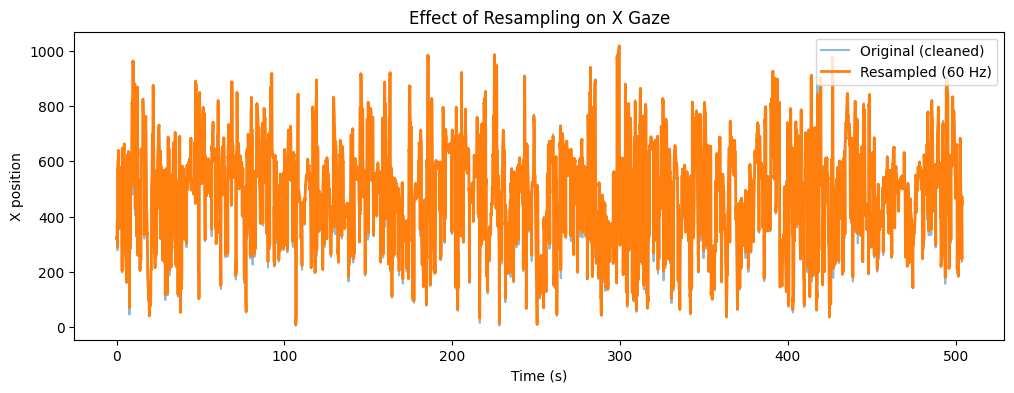

In [281]:
# visual check of the resampled data

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(timestamps, x, label='Original (cleaned)', alpha=0.5)
plt.plot(uniform_timestamps, x_resampled, label='Resampled (60 Hz)', linewidth=2)
plt.legend()
plt.title('Effect of Resampling on X Gaze')
plt.xlabel('Time (s)')
plt.ylabel('X position')
plt.show()


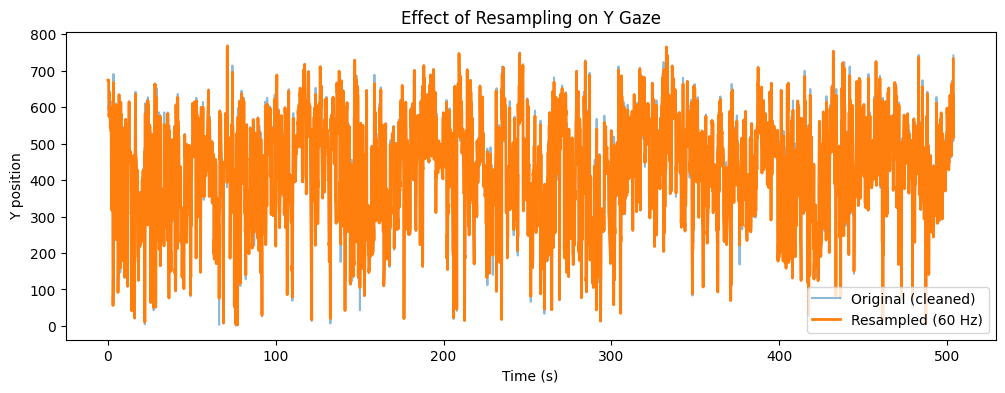

In [282]:
# visual check of the resampled data

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(timestamps, y, label='Original (cleaned)', alpha=0.5)
plt.plot(uniform_timestamps, y_resampled, label='Resampled (60 Hz)', linewidth=2)
plt.legend()
plt.title('Effect of Resampling on Y Gaze')
plt.xlabel('Time (s)')
plt.ylabel('Y position')
plt.show()


In [116]:
import numpy as np
import pandas as pd

participant_id_1 = "pilot_03"  # Adjust per participant
movie_type = "sprout_run_02"   #sprout_run_02, prayer_run_01
dir_1 = f"/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/{movie_type}/" 

# Assume your original data has timestamps in milliseconds
# and x, y values with some NaNs
data = pd.read_csv(os.path.join(dir_1, f"{movie_type}_{participant_id_1}_filtered_eye_data.csv"))
df = pd.DataFrame(data)

timestamps = df['timestamp'].values

In [13]:
movie_start_tick = eye_tracker_tick_start + delta_ticks

print("Movie start tick:", movie_start_tick)

Movie start tick: 6941660172244


In [ ]:
#checking the duration of the movies in seconds
from pymediainfo import MediaInfo
movie_name = "prayer_part_02_NoCal.mp4"
video_file = MediaInfo.parse(f"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/{movie_name}")
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        video_duration = duration_ms / 1000
        print(f"Duration: {video_duration:.2f} seconds")

Duration: 779.60 seconds


In [270]:
eye_tracker_datetime = "2025/05/30 10:39:39.669" #pilot_05  prayer_run_01 : "2025/05/30 10:05:41.056"               #for pilot 05 sprout_run_02: "2025/05/30 10:50:52.875"    #for pilot 05 sprout run 01: eye_tracker_datetime = TIME(2025/05/30 10:39:39.669)
eye_tracker_tick_start =  6961666979596             #pilot_05  prayer_run_01 : 6941280752244               #for pilot 05 sprout_run_02: 6968398866220  #for pilot 05, sprout run 01: 6961666979596
movie_start_datetime = "2025-05-30 10:40:01.552"     #pilot_05  prayer_run_01 : "2025-05-30 10:06:18.998"                 #for pilot 05 sprout_run_02: "2025-05-30 10:51:11.010" #for pilot 05 sprout run 01: 2025-05-30_10h40.01.552
tick_frequency = 10_000_000

#eye_tracker_datetime = "2025/06/04 10:03:00.170"                                 #for pilot 06 sprout_run_02: "2025/06/04 10:03:00.170" 
#eye_tracker_tick_start = 11259631341375                                  #for pilot 06  sprout_run_02: 11259631341375  
#movie_start_datetime =  "2025-06-04 10:03:24.846"                      #for pilot 06  sprout_run_02: "2025-06-04 10:03:24.846"     

# Convert to datetime objects
dt_eye = datetime.strptime(eye_tracker_datetime, "%Y/%m/%d %H:%M:%S.%f")
dt_movie = datetime.strptime(movie_start_datetime, "%Y-%m-%d %H:%M:%S.%f")

# Compute time difference in seconds
delta_seconds = (dt_movie - dt_eye).total_seconds()

# Convert to time ticks
delta_ticks = int(delta_seconds * tick_frequency)

# Final movie start time tick
movie_start_tick = eye_tracker_tick_start + delta_ticks

In [368]:
#df = pd.DataFrame(data)
df["timestamp"]


0          0.000000
1          0.016621
2          0.032946
3          0.049257
4          0.065660
            ...    
38594    634.041427
38595    634.057681
38596    634.074041
38597    634.090646
38598    634.107132
Name: timestamp, Length: 38599, dtype: float64

# getting more uniform timestamps 

In [370]:



import os
import pandas as pd
import numpy as np
from glob import glob


# Parameters

#participant_id = "pilot_04"  # Adjust per participant
#movie_type = "sprout_run_02"   #sprout_run_02, prayer_run_01


participant_id = "pilot_mina"  # Adjust per participant
movie_type = "sprout_run_02" # Adjust per movie type

data = os.path.join(os.path.dirname(output_dir),f"{movie_type}_{participant_id}_filtered_eye_data.csv")


#data_dir = f"/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/{movie_type}/"         # Folder with original CSV files
output_dir = dir_1 = f"/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/{movie_type}/"    # Folder to save aligned files


#data = pd.read_csv(os.path.join(data_dir, f"{movie_type}_{participant_id}_filtered_eye_data.csv"))
df = pd.read_csv(data)
df = pd.DataFrame(df)


movie_duration_sec = 634.12        # Total duration of movie in seconds; adjust per movie: sprout_run_02 = 634.12; sprout_part_01= 503.87 ; prayer_run_01 = 709.47; prayer_run_02 = 779.60;
target_sampling_rate = 60       # Hz
uniform_timestamps = np.linspace(0, movie_duration_sec, int(movie_duration_sec * target_sampling_rate))

# Ensure output folder exists
os.makedirs(output_dir, exist_ok=True)

# Helper function to match closest original timestamp
def align_to_uniform_timestamps(df, uniform_ts):
    orig_ts = df["timestamp"].values
    x = df["x"].values
    y = df["y"].values

    # Use numpy searchsorted for fast matching
    idxs = np.searchsorted(orig_ts, uniform_ts, side="left")

    # Handle edge cases
    idxs[idxs >= len(orig_ts)] = len(orig_ts) - 1

    # Get matched gaze data
    matched_x = x[idxs]
    matched_y = y[idxs]
    matched_orig_ts = orig_ts[idxs]

    return pd.DataFrame({
        "uniform_timestamp": uniform_ts,
        "matched_original_timestamp": matched_orig_ts,
        "x": matched_x,
        "y": matched_y
    })


# Align data to uniform timestamps

aligned_df = align_to_uniform_timestamps(df, uniform_timestamps)
aligned_df.to_csv(os.path.join(output_dir, f"{movie_type}_{participant_id}_filtered_uniform_timestamps.csv"), index=False)

print(f"Aligned data saved to {output_dir}")




Aligned data saved to /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_02/


In [371]:
aligned_df 

,uniform_timestamp,matched_original_timestamp,x,y
0,0.000000,0.000000,627.20000,378.45504
1,0.016667,0.032946,629.74976,381.07392
2,0.033334,0.049257,630.66112,385.09824
3,0.050002,0.065660,631.21408,389.72928
4,0.066669,0.082048,632.01280,394.19904
...,...,...,...,...
38042,634.053331,634.057681,594.03264,367.99488
38043,634.069998,634.074041,596.74624,371.39712
38044,634.086666,634.090646,613.25312,393.30048
38045,634.103333,634.107132,625.77664,390.09792


1.2954039069381833

In [306]:
import numpy as np

# Create uniform timestamps (e.g., for 60 Hz)
uniform_timestamps = np.linspace(0, 634, num=38040)  # From 0 to 634 seconds, 38040 points


In [308]:
uniform_timestamps[0:100]

array([0.        , 0.0166671 , 0.03333421, 0.05000131, 0.06666842,
       0.08333552, 0.10000263, 0.11666973, 0.13333684, 0.15000394,
       0.16667105, 0.18333815, 0.20000526, 0.21667236, 0.23333947,
       0.25000657, 0.26667368, 0.28334078, 0.30000789, 0.31667499,
       0.3333421 , 0.3500092 , 0.36667631, 0.38334341, 0.40001052,
       0.41667762, 0.43334473, 0.45001183, 0.46667893, 0.48334604,
       0.50001314, 0.51668025, 0.53334735, 0.55001446, 0.56668156,
       0.58334867, 0.60001577, 0.61668288, 0.63334998, 0.65001709,
       0.66668419, 0.6833513 , 0.7000184 , 0.71668551, 0.73335261,
       0.75001972, 0.76668682, 0.78335393, 0.80002103, 0.81668814,
       0.83335524, 0.85002235, 0.86668945, 0.88335656, 0.90002366,
       0.91669076, 0.93335787, 0.95002497, 0.96669208, 0.98335918,
       1.00002629, 1.01669339, 1.0333605 , 1.0500276 , 1.06669471,
       1.08336181, 1.10002892, 1.11669602, 1.13336313, 1.15003023,
       1.16669734, 1.18336444, 1.20003155, 1.21669865, 1.23336

In [138]:

participant_id = "pilot_05"  # Adjust per participant
movie_type = "witness_run_01" # Adjust per movie type
movie_name = "witness_part_01_NoCal.mp4" #adjust how it is in folder with movies 

eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/witness/{participant_id}_{movie_type}/User 0_fixations.csv"
df = pd.read_csv(eye_data_file)

In [139]:
df

,MEDIA_ID,MEDIA_NAME,CNT,TIME(2025/05/29 10:15:03.932),TIMETICK(f=10000000),FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,...,DIALV,TTL6,TTLV,PIXS,PIXV,AOI,SACCADE_MAG,SACCADE_DIR,VID_FRAME,Unnamed: 47
0,0,pilot_05_witness_run_01,12,0.19691,6082926424518,0.56642,1.12927,0.00000,0.19690,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
1,0,pilot_05_witness_run_01,91,1.49499,6082939405386,0.56051,1.11354,0.21323,1.28176,2,...,0,1,0,0.0,0,NaN,13.51167,116.60903,0,NaN
2,0,pilot_05_witness_run_01,128,2.10246,6082945480067,0.55523,1.12039,1.51110,0.59135,3,...,0,1,0,0.0,0,NaN,7.54380,224.21687,0,NaN
3,0,pilot_05_witness_run_01,147,2.41496,6082948605147,0.55181,1.10603,2.11896,0.29601,4,...,0,1,0,0.0,0,NaN,11.57125,107.61703,0,NaN
4,0,pilot_05_witness_run_01,189,3.10498,6082955505313,0.53866,1.10819,2.43118,0.67380,5,...,0,1,0,0.0,0,NaN,13.56743,187.02280,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2532,0,pilot_05_witness_run_01,71346,1172.10400,6094645496758,-0.28454,1.00778,1171.87402,0.22998,2533,...,0,1,0,0.0,0,NaN,150.69150,19.64967,0,NaN
2533,0,pilot_05_witness_run_01,71372,1172.53125,6094649768273,-0.18046,0.96930,1172.16968,0.36157,2534,...,0,1,0,0.0,0,NaN,110.59931,15.49797,0,NaN
2534,0,pilot_05_witness_run_01,71383,1172.71191,6094651575700,-0.26482,1.02864,1172.59717,0.11487,2535,...,0,1,0,0.0,0,NaN,97.66894,207.81438,0,NaN
2535,0,pilot_05_witness_run_01,71411,1173.17188,6094656175142,-0.05489,1.11550,1172.97485,0.19714,2536,...,0,1,0,0.0,0,NaN,225.08086,342.75998,0,NaN


In [140]:
eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/witness/{participant_id}_{movie_type}/User 0_all_gaze.csv"
df_1 = pd.read_csv(eye_data_file)

In [141]:
df_1

,MEDIA_ID,MEDIA_NAME,CNT,TIME(2025/05/29 10:15:03.932),TIMETICK(f=10000000),FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,...,DIALV,TTL6,TTLV,PIXS,PIXV,AOI,SACCADE_MAG,SACCADE_DIR,VID_FRAME,Unnamed: 47
0,0,pilot_05_witness_run_01,0,0.00000,6082924455644,0.57283,1.12402,0.00000,0.00001,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
1,0,pilot_05_witness_run_01,1,0.01609,6082924616441,0.57252,1.12316,0.00000,0.01609,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
2,0,pilot_05_witness_run_01,2,0.03255,6082924781009,0.57229,1.12294,0.00000,0.03255,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
3,0,pilot_05_witness_run_01,3,0.04897,6082924945271,0.57202,1.12308,0.00000,0.04897,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
4,0,pilot_05_witness_run_01,4,0.06546,6082925110245,0.57171,1.12352,0.00000,0.06547,1,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71423,0,pilot_05_witness_run_01,71423,1173.36914,6094658146942,-0.11692,1.12090,1173.18848,0.18066,2537,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
71424,0,pilot_05_witness_run_01,71424,1173.38574,6094658313472,-0.11564,1.12203,1173.18848,0.19727,2537,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
71425,0,pilot_05_witness_run_01,71425,1173.40210,6094658475367,-0.11609,1.12387,1173.18848,0.21350,2537,...,0,1,0,0.0,0,NaN,0.00000,0.00000,0,NaN
71426,0,pilot_05_witness_run_01,71426,1173.41846,6094658640982,-0.11607,1.12427,1173.18848,0.22998,2537,...,0,1,0,0.0,0,NaN,63.00935,186.13634,0,NaN


#### script for pilot 05 and 06 (cause for these partcipants I added pressing "space" before movie to help with time alignement)
#### for pilot 04 it was the first time when license expired and so here it is not possible to get the exact beginning 
##### (but I think it actually recorded it from the start cause when I exported the movie it did nto show any delay in recording at least for sprout)

In [168]:
####### I want to trim the data to the length of the video
# ## ANOTHER VERSION JUST FOR PILOT 05 and 06!!!!!!! 

from datetime import datetime


# File paths
#video_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/movies/NO_CAL_GUEST_part01.mp4"
#eye_data_file = "/Users/olga.gulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot01/sprout_run2_pilot01/pilot_01_all_gaze.csv" #for my airmac

participant_id = "pilot_06"  # Adjust per participant
movie_folder = "guest"
movie_type = "guest_run_02" # Adjust per movie type
movie_name = "NO_CAL_GUEST_part02.mp4" #"witness_part_02_NoCal.mp4" #adjust how it is in folder with movies 

eye_data_file = f"/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/{participant_id}/{movie_folder}/{participant_id}_{movie_type}/User 1_fixations.csv"  #User 1_all_gaze.csv"

output_dir = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/" 





# load the video and get its duration in seconds
#video_file = "/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/prayer_part_01_NoCal.mp4"
#cap = cv2.VideoCapture(video_file)
#fps = int(cap.get(cv2.CAP_PROP_FPS))
#frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
#video_duration = frame_count / fps
#cap.release()
#print(f"Video duration: {video_duration:.2f} seconds")
#video_duration_01 = 709

#more accurate way of getting the video duration
from pymediainfo import MediaInfo

video_file = MediaInfo.parse(f"/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/{movie_name}")
for track in video_file.tracks:
    if track.track_type == "General":
        duration_ms = track.duration
        video_duration = duration_ms / 1000
        print(f"Duration: {video_duration:.2f} seconds")

# Load and preprocess eye-tracking data
eye_data = pd.read_csv(eye_data_file)

columns = ["FPOGX", "FPOGY", "TIMETICK(f=10000000)"] #"TIME(2025/03/26 11:06:32.014)    "TIMETICK(f=10000000)"

coord_data = eye_data[columns].copy()


#trimmnng the intial part of the eye tracking data to match the start of the movie

## contuning with the conversion of datetime to time ticks (here is specfic for pilot 05 sprout part 2)


# Given values
#eye_tracker_datetime = "2025/05/30 10:50:52.875" #pilot_05  prayer_run_01 : "2025/05/30 10:05:41.056"               #for pilot 05 sprout_run_02: "2025/05/30 10:50:52.875"    #for pilot 05 sprout run 01: eye_tracker_datetime = TIME(2025/05/30 10:39:39.669)
#eye_tracker_tick_start =  6968398866220              #pilot_05  prayer_run_01 : 6941280752244                       #for pilot 05 sprout_run_02: 6968398866220              #for pilot 05, sprout run 01: 6961666979596
#movie_start_datetime = "2025-05-30 10:51:11.010"     #pilot_05  prayer_run_01 : "2025-05-30 10:06:18.998"           #for pilot 05 sprout_run_02: "2025-05-30 10:51:11.010"    #for pilot 05 sprout run 01: 2025-05-30_10h40.01.552
tick_frequency = 10_000_000

#eye_tracker_datetime = "2025/06/04 10:03:00.170"                              #for pilot 06 sprout_run_02: "2025/06/04 10:03:00.170"    #for pilot 06 sprout run 01: TIME(2025/06/04 09:49:15.532)
#eye_tracker_tick_start = 11259631341375                                #for pilot 06  sprout_run_02: 11259631341375  #for pilot 06 sprout run 01: 11251384914710
#movie_start_datetime =  "2025-06-04 10:03:24.846"                    #for pilot 06  sprout_run_02: "2025-06-04 10:03:24.846"       # for pilot 06 sprout run 01: "2025-06-04 09:49:51.449"  

#eye_tracker_datetime = "2025/05/30 10:39:39.669"  #for pilot 05 sprout run 01 
#eye_tracker_tick_start = 6961666979596           #for pilot 05 sprout run 01 
#movie_start_datetime = "2025-05-30 10:40:01.552" #for pilot 05 sprout run 01 

#eye_tracker_datetime = "2025/06/04 09:49:15.532" #for pilot 06 sprout run 01
#eye_tracker_tick_start = 11251384914710          #for pilot 06 sprout run 01
#movie_start_datetime = "2025-06-04 09:49:51.448" #for pilot 06 sprout run 01

eye_tracker_datetime = "2025/06/04 10:37:28.623"   #pilot 06 guest run-2"2025/06/04 10:37:28.623"     #pilot05 prayer run 02 = "2025/05/30 10:22:13.368"   #for pilot 05 prayer run 01: "2025/05/30 10:05:41.056"  #pilot 05, witness run01: "2025/05/29 10:15:03.932"  run 02 "2025/05/29 10:35:25.609" "
eye_tracker_tick_start = 11280320350854 # pilot 06 guest run-2: 11280315913352   #pilot05 prayer run 02  =  6951203862735     #for pilot 05 prayer run 01: 6941280752244   # pilot 05 witness run 01:  6082924455644 run02: 6095141470093 
movie_start_datetime = "2025-06-04 10:37:18.648"  #pilot05 prayer run 02 ="2025-05-30 10:22:07.870"    #for pilot 05 prayer run 01: "2025-05-30 10:06:18.998" #pilot 05 witness run 01 : 2025-05-29_10h17.56.293 run 02:"2025-05-29 10:36:17.558" 


#eye_tracker_datetime =                    #pilot06 prayer run 01: "2025/06/05 10:20:58.454"  # pilot 06 witness run01:"2025/06/05 10:51:29.183" run 02: "2025/06/05 11:07:56.311"
#eye_tracker_tick_start =                           #pilot06 prayer run 01: i forgot to paste it #  pilot 06 witness run01: forgot to paste run 02: 12162581215033
#movie_start_datetime =                  #pilot06 prayer run 01:"2025-06-05 10:21:24.201"  #pilot 06 witness run01: "2025-06-05 10:51:26.697" run 02: "2025-06-05 11:08:20.304" 

# Convert to datetime objects
dt_eye = datetime.strptime(eye_tracker_datetime, "%Y/%m/%d %H:%M:%S.%f")
dt_movie = datetime.strptime(movie_start_datetime, "%Y-%m-%d %H:%M:%S.%f")

# Compute time difference in seconds
delta_seconds = (dt_movie - dt_eye).total_seconds()

# Convert to time ticks
delta_ticks = int(delta_seconds * tick_frequency)

# Final movie start time tick
movie_start_tick = eye_tracker_tick_start + delta_ticks

print("Movie start tick:", movie_start_tick)

# Keep only rows at or after movie start tick
coord_data = coord_data[coord_data["TIMETICK(f=10000000)"] >= movie_start_tick].copy()
# Then reset so that TIMETICK starts at 0
coord_data["TIMETICK(f=10000000)"] -= movie_start_tick #


coord_data["timestamp"] = coord_data["TIMETICK(f=10000000)"] / 10000000



### ______________


# Trim to match video duration
coord_data = coord_data[coord_data["timestamp"] <= video_duration].reset_index(drop=True)

#count zeros and negatives in the data
count_zeros_x = (coord_data["FPOGX"] == 0).sum()
count_zeros_y = (coord_data["FPOGY"] == 0).sum()
count_negatives_x = (coord_data["FPOGX"] < 0).sum()
count_negatives_y = (coord_data["FPOGY"] < 0).sum()

#replacing the zero, negative or higher than 1 values with NaN (important for interpolation)

coord_data["FPOGX"] = coord_data["FPOGX"].mask((coord_data["FPOGX"] <= 0) | (coord_data["FPOGX"] > 1), np.nan)
coord_data["FPOGY"] = coord_data["FPOGY"].mask((coord_data["FPOGY"] <= 0) | (coord_data["FPOGY"] > 1), np.nan)


#interpolating the Nan values with the linear function
coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='linear', limit_direction='both')
coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='linear', limit_direction='both')

#Spline way of interpolating the zero values

#coord_data["FPOGX"] = coord_data["FPOGX"].interpolate(method='spline', order=2, limit_direction='both')
#coord_data["FPOGY"] = coord_data["FPOGY"].interpolate(method='spline', order=2, limit_direction='both')


#optoionally I can cl1ip the values to be between 0 and 1, in case the interpolation overshoots if there is a sharp jump in eye gaze
#coord_data["FPOGX"] = coord_data["FPOGX"].clip(0, 1)
#coord_data["FPOGY"] = coord_data["FPOGY"].clip(0, 1)


#screen resolution
screen_width = 1024
screen_height = 768  

# Compute pixel coordinates
coord_data["x"] = coord_data["FPOGX"] * screen_width

#coord_data["y"] = coord_data["FPOGY"] * screen_height

coord_data["y"] = (1 - coord_data["FPOGY"]) * screen_height #Ali's suggestion of scaling the y's coordinates

#keep only rows where x and y coordinates are within the screen resolution
#valid_coords = (coord_data["x"] <= screen_width) & (coord_data["y"] <= screen_height) # there seems to be no difference between 


# Apply the filter to the entire DataFrame

#filtered_data = coord_data[valid_coords].copy()
filtered_data = []
filtered_data = coord_data[["x", "y", "timestamp"]]


#checking if the x and y are within the screen resolution
print("x and y coordinates, resepctively maximum value (to see if is within screen resolution", filtered_data["x"].max(), filtered_data["y"].max())
print("x and y coordinates, resepctively minimum value (to see if is within screen resolution:", filtered_data["x"].min(), "," ,filtered_data["y"].min())


#double check that there are no neative numbers left
negative_count = (filtered_data["x"] < 0).sum()
negative_count_y = (filtered_data["y"] < 0).sum()
print("Number of negative values in x_coord and y_coord:", negative_count, negative_count_y)

zeros = (filtered_data["x"] == 0).sum()
zeros_y = (filtered_data["x"] == 0).sum()
print("Number of zeros in x_coord", zeros, zeros_y)



filtered_some_data = filtered_data[["timestamp", "x", "y"]].copy()




# save the filtered data to a new CSV file
saved_data_file = os.path.join(os.path.dirname(output_dir),f"{movie_type}_{participant_id}_filtered_eye_data_fixations.csv") #_fixations if fixation file used
filtered_some_data.to_csv(saved_data_file, index=False)
print(f"Filtered eye-tracking data saved to {saved_data_file}")

Duration: 496.30 seconds
Movie start tick: 11280220600854
x and y coordinates, resepctively maximum value (to see if is within screen resolution 1009.17248 755.6351999999999
x and y coordinates, resepctively minimum value (to see if is within screen resolution: 17.3056 , 3.1564799999999593
Number of negative values in x_coord and y_coord: 0 0
Number of zeros in x_coord 0 0
Filtered eye-tracking data saved to /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/guest_run_02_pilot_06_filtered_eye_data_fixations.csv


In [143]:
filtered_some_data

,timestamp,x,y
0,0.465442,561.45920,369.04704
1,0.876155,760.33024,278.64576
2,1.122482,754.29888,239.20128
3,1.582572,660.54144,266.28096
4,1.845353,639.94880,288.06144
...,...,...,...
1920,862.942623,378.12224,385.39008
1921,863.123332,430.10048,422.91456
1922,863.616062,334.46912,406.60992
1923,863.911816,366.33600,359.24736


<Axes: title={'center': 'Eye Tracking Data for pilot_05 - witness_run_01'}, xlabel='Time (s)', ylabel='Pixel Coordinates'>

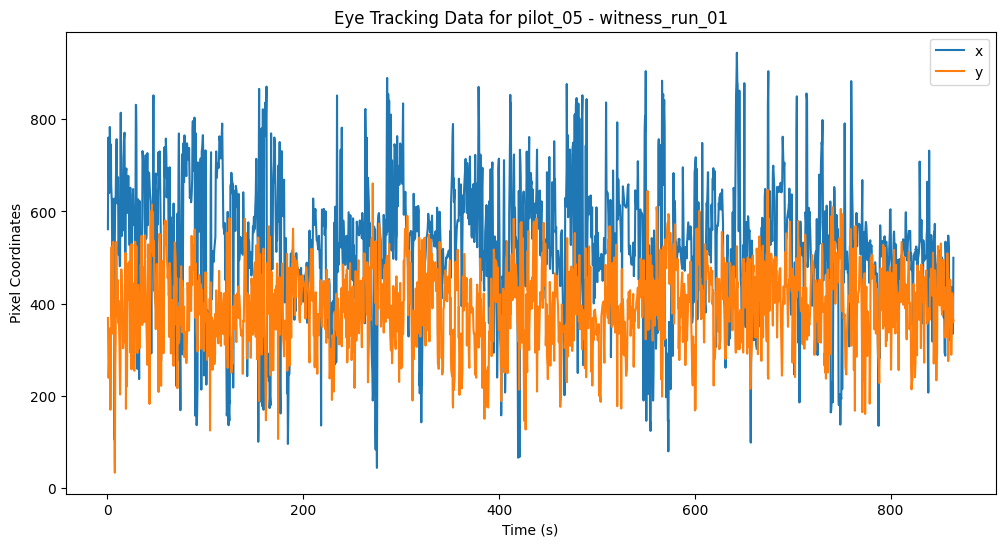

In [146]:
#plotting raw eye tracking data

filtered_some_data.plot(x='timestamp', y=['x', 'y'], title=f'Eye Tracking Data for {participant_id} - {movie_type}', xlabel='Time (s)', ylabel='Pixel Coordinates', figsize=(12, 6))

In [144]:
count = count_zeros_y + count_zeros_x + count_negatives_y + count_negatives_x
print("Total number of zeros and negatives in the data:", count)

Total number of zeros and negatives in the data: 0


In [134]:
60-22

38

In [129]:
eye_data_file

'/Users/olgagulka/Desktop/IBS/memory_experiment/raw_results/eye_tracking/eye_tracking_exported/pilot_06/witness/pilot_06_witness_run_01/User 1_all_gaze.csv'

In [126]:
movie_start_tick/10000000

1215268.4989984

In [128]:
dt_movie

datetime.datetime(2025, 6, 5, 10, 51, 26, 697000)

In [ ]:
# Final movie start time tick
movie_start_tick = eye_tracker_tick_start + delta_ticks

print("Movie start tick:", movie_start_tick)

# Keep only rows at or after movie start tick
coord_data = coord_data[coord_data["TIMETICK(f=10000000)"] >= movie_start_tick].copy()

np.float64(23.85035881758595)

In [60]:
coord_data

,FPOGX,FPOGY,TIMETICK(f=10000000),timestamp,x,y


In [56]:
coord_data[coord_data["TIMETICK(f=10000000)"] > movie_start_tick]

,FPOGX,FPOGY,TIMETICK(f=10000000),timestamp,x,y


In [ ]:
coord_data = coord_data[coord_data["TIMETICK(f=10000000)"] >= movie_start_tick].copy()

In [ ]:
#pilot 06 sprout run 02: above 1, zeros or negative = 11848 (mostly zero values) out of 38598 (so it is 30.7% of the data)
#pilot 05 sprout run 02: above 1, zeros or negative = 9206 out of 38599 (so it is 23.8% of the data)

Series([], Name: x, dtype: float64)

In [19]:
1184800/38598

30.695890978807192

In [25]:
(coord_data["TIMETICK(f=10000000)"] < movie_start_tick).sum()

np.int64(2310)

In [24]:
len(coord_data["TIMETICK(f=10000000)"])

50457

## Combining the two parts of the movie into one

In [ ]:

import numpy as np
import pandas as pd
import os

participant_id_part01= "pilot_05"  # Adjust per participant
participant_id_part02 = "pilot_05" #adjust per participant
movie_type = "sprout_run_01"   # prayer_run_01
movie_type_part_02 = "sprout_run_02" # Adjust per movie type
dir_01 = f"/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/{movie_type}/{movie_type}_{participant_id_x}_filtered_eye_data_resampled.csv" 
dir_02 = f"/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/{movie_type}/{movie_type_part_02}_{participant_id_y}_filtered_eye_data_resampled.csv"

#data = pd.read_csv(os.path.join(dir_1, f"{movie_type}_{participant_id_1}_filtered_eye_data.csv"))
#df = pd.DataFrame(data)

#concatenate the two dataframes
data_01 = pd.read_csv(dir_01)
data_02 = pd.read_csv(dir_02)



In [290]:
data_x

,timestamp,x,y
0,0.016330,497.152000,460.546560
1,0.032997,497.016246,462.837907
2,0.049663,496.963061,464.723537
3,0.066330,497.885121,465.523018
4,0.082997,497.435704,466.090707
...,...,...,...
30226,503.782997,430.117461,557.505770
30227,503.799663,433.145564,543.749427
30228,503.816330,435.002677,531.523936
30229,503.832997,435.798741,519.103083


## Downsmapling of the results - although I do not do it anymore

In [ ]:
### changed version of downsampling where I have a more accurate, evenly spaced timestamps 

import pandas as pd
import numpy as np
import os

# Output directory

participant_id_1 = "pilot_06"  # Adjust per participant
movie_type = "sprout_run_02"   #sprout_run_02, prayer_run_01
dir_1 = f"/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/{movie_type}/"     
output_dir_1 = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_downsampled/"


saved_data_file = os.path.join(os.path.dirname(dir_1), f"{movie_type}_{participant_id_1}_filtered_eye_data.csv")   #CORRECTED


# Load filtered data
processed_data = pd.read_csv(saved_data_file)

def downsample_eye_data(df, target_fps=23, method='mean'):
    df = df.copy()
    
    # Generate target timestamps aligned with video frames
    video_duration = df["timestamp"].max()
    num_frames = int(video_duration * target_fps)
    target_times = np.linspace(0, video_duration, num=num_frames, endpoint=False)
    exact_times = pd.to_timedelta(target_times, unit='s')

    #Convert timestamps for high-resolution resampling
    df["timestamp"] = pd.to_timedelta(df["timestamp"], unit='s')
    df.set_index("timestamp", inplace=True)

    # Resample at high frequency (1ms), then interpolate
    if method == 'median':
        resampled = df.resample('1ms').median().interpolate()
    else:
        resampled = df.resample('1ms').mean().interpolate()

    # Interpolate gaze data at exact movie frame timestamps
    resampled = resampled.reindex(resampled.index.union(exact_times)).interpolate(method='time')
    downsampled = resampled.loc[exact_times].copy()
    downsampled.reset_index(inplace=True)
    downsampled["rel_time"] = downsampled["index"].dt.total_seconds()   #downsampled["timestamp"] = downsampled["timestamp"].dt.total_seconds()
    


    return downsampled

# Apply function
downsampled_data = downsample_eye_data(processed_data, target_fps=23)

# Save result
saved_data_file_downsampled = os.path.join(output_dir_1, f"{movie_type}_{participant_id_1}_downsampled_eye_data.csv")
os.makedirs(output_dir_1, exist_ok=True)
downsampled_data.to_csv(saved_data_file_downsampled, index=False)

print(f"Downsampled eye-tracking data saved to: {saved_data_file_downsampled}")



FileNotFoundError: [Errno 2] No such file or directory: '/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_02_pilot_05_filtered_eye_data.csv'

In [ ]:


## verifyng whether the downsampled data matches the number of video frames of my video

# Calculate the duration of the downsampled data
#start_time = downsampled_data["timestamp"].min()
#end_time = downsampled_data["timestamp"].max()
#duration = end_time - start_time

duration = 661.74 # for sprout run 02 pilot 04

# Calculate expected and actual number of frames
expected_frames = int(duration * 23)  # or whatever your target_fps is
actual_frames = len(downsampled_data)

print(f"\nDuration: {duration:.2f} seconds")
print(f"Expected number of frames at 23 FPS: {expected_frames}")
print(f"Actual number of downsampled samples: {actual_frames}")
print(f"Difference: {actual_frames - expected_frames}")



Duration: 661.74 seconds
Expected number of frames at 23 FPS: 15220
Actual number of downsampled samples: 15274
Difference: 54


In [63]:

eye_data["timeick"] = eye_data["TIMETICK(f=10000000)"]/ 10000000
np.shape(eye_data["timeick"])

(40426,)

6941660172244

In [15]:
saved_data_file

'/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_02_pilot_03_filtered_eye_data.csv'

## Creating heatmaps

#### version where I select gaze points based on a timestamp window around each video frame 

In [ ]:
import cv2
import pandas as pd
import numpy as np

# File paths
#video_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/movies/NO_CAL_GUEST_part01.mp4"
#eye_data_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/raw_data_for_MoCET/merged_with_column_names_s10.csv"
#output_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/heatmap_s10_guest_part1.mp4"
video_file = "/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_02_NoCal.mp4"
eye_gaze_processed = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_02_pilot_04_filtered_eye_data.csv"
output_file = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_heatmap_movies/heatmap_pilot_04_sprout_run_02.mp4"

# Load and preprocess eye-tracking data
eye_data = pd.read_csv(eye_gaze_processed)



# Drop invalid rows
eye_data = eye_data.dropna(subset=['x', 'y'])

# Open the video file
cap = cv2.VideoCapture(video_file)
fps = int(cap.get(cv2.CAP_PROP_FPS))


# Check if the video file opened successfully
if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()

#getting the resolution of the movie 
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Calculate video duration
video_duration = frame_count / fps

# Debugging: Log video and gaze data details
print(f"Video FPS: {fps}, Duration: {video_duration:.2f} seconds")
print(f"Gaze data timestamp range: {eye_data['timestamp'].min()} to {eye_data['timestamp'].max()}")

# Scale gaze timestamps if needed
gaze_duration = eye_data['timestamp'].max() - eye_data['timestamp'].min()
if abs(gaze_duration - video_duration) > 0.1:
    scaling_factor = video_duration / gaze_duration
    print(f"Scaling gaze timestamps by factor {scaling_factor:.6f}")
    eye_data['timestamp'] *= scaling_factor


# Define the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, fps, (frame_width, frame_height))


screen_width = 1024
screen_height = 768
 
#remove this cropping part 
#defining the black are of the screen (1024/1.6 = 640) [where 1.6 is the ratio of the movie resolution] 768-640 = 128pixels, which means that I need to crop 64 pixels from the top and the bottom.
top_crop = 64
bottom_crop = 64
visible_height =  screen_height - top_crop - bottom_crop

#normalizing the values to the resolution of the movie (cause the resolution of the movie is different to the resolution of the screen in the experimental room)

#eye_data['x'] = eye_data['x'] * (frame_width / screen_width)
#eye_data['y'] = eye_data['y'] * (frame_height / screen_height)

# cropping the black area in y-axis and rescaling to the viisble height
eye_data['y'] = (eye_data['y'] - top_crop) * (frame_height / visible_height)
#there is no horizontla cropping, so I just need to rescale the x-axis
eye_data['x'] = eye_data['x'] * (frame_width / screen_width)

# Clip gaze coordinates to ensure they are within valid ranges
eye_data['x'] = eye_data['x'].clip(0, frame_width - 1)
eye_data['y'] = eye_data['y'].clip(0, frame_height - 1)


# Iterate through video frames
frame_idx = 0
tolerance = 6 / fps  # Increased tolerance (~200 ms) previously it was 2/fps

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    

    # Calculate current timestamp for the frame
    current_time = frame_idx / fps

   

    # Select gaze points for the current frame
    gaze_points = eye_data[
        (eye_data['timestamp'] >= current_time - tolerance) &
        (eye_data['timestamp'] < current_time + tolerance)
    ]

    # Create a blank heatmap for the current frame
    heatmap = np.zeros((frame_height, frame_width), dtype=np.float32)

    # Accumulate gaze points into the heatmap
    for _, point in gaze_points.iterrows():
        x, y = int(point['x']), int(point['y'])
        if 0 <= x < frame_width and 0 <= y < frame_height:
            heatmap[y, x] += 1  # Increment heatmap intensity at gaze point
            

    # Apply Gaussian blur to spread intensity across nearby pixels
    heatmap = cv2.GaussianBlur(heatmap, (1001, 1001), 0)  #It was 1001,1001 before

    # Normalize the heatmap to a range (0, 255)
    heatmap = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX)

    # Convert heatmap to a color map
    heatmap_color = cv2.applyColorMap(heatmap.astype(np.uint8), cv2.COLORMAP_JET)

    # Blend the heatmap with the cropped frame
    blended_frame = cv2.addWeighted(frame, 0.6, heatmap_color, 0.4, 0)

    # Write the frame with heatmap overlay
    out.write(blended_frame)
    frame_idx += 1

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Heatmap video saved as {output_file}")


Video FPS: 23, Duration: 661.74 seconds
Gaze data timestamp range: 0.0 to 662.62756
Scaling gaze timestamps by factor 0.998659
Heatmap video saved as /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_heatmap_movies/heatmap_pilot_04_sprout_run_02.mp4


In [ ]:
#check what is the maximum value of the frame 
#interpolation, smoothing, and then downsampling
#check if the FPOG values are updated before you start the calibration 

In [23]:


eye_gaze_processed = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_02_pilot_04_filtered_eye_data.csv"
eye_data = pd.read_csv(eye_gaze_processed)
eye_data


,timestamp,rel_time,x,y
0,0.00000,0.000000,521.70752,336.15360
1,0.01660,0.016536,525.41440,339.37920
2,0.03284,0.032765,529.07008,344.35584
3,0.04944,0.049434,532.17280,349.78560
4,0.06592,0.065901,556.92288,364.50816
...,...,...,...,...
26007,662.56201,662.561953,331.86816,92.23680
26008,662.57849,662.578438,331.86816,92.23680
26009,662.59485,662.594862,331.86816,92.23680
26010,662.61121,662.611188,331.86816,92.23680


In [ ]:
pd.read_csv(eye_gaze_processed)

'/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/downsampled_filtered_eye_data/sprout_run_02_pilot_04_22_05_downsampled_eye_data.csv'

### updated version 16/05 where I grab the gaze points for each frame

In [ ]:
import cv2
import pandas as pd
import numpy as np

# File paths
#video_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/movies/NO_CAL_GUEST_part01.mp4"
#eye_data_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/raw_data_for_MoCET/merged_with_column_names_s10.csv"
#output_file = "/Users/olga.gulka/Desktop/IBS/eye_tracking/heatmap_s10_guest_part1.mp4"
video_file = "/Users/olgagulka/Desktop/IBS/eye_tracking/movies/SPROUT_NATPAC_02.mp4"     # "/Users/olgagulka/Desktop/IBS/eye_tracking/movies_withoutCali/sprout_part_02_NoCal.mp4"
eye_gaze_processed = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/downsampled_filtered_eye_data/sprout_run_02_pilot_04_22_05_downsampled_eye_data.csv"    # "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_filtered/sprout_run_02_pilot_04_18_05_filtered_eye_data.csv"
output_file = "/Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_heatmap_movies/heatmap_pilot_04_sprout_run_02_18_05.mp4"

# Load and preprocess eye-tracking data
eye_data = pd.read_csv(eye_gaze_processed)



# Drop invalid rows
eye_data = eye_data.dropna(subset=['x', 'y'])

# Open the video file
cap = cv2.VideoCapture(video_file)
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Check if the video file opened successfully
if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()

#getting the resolution of the movie 
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Calculate video duration
video_duration = frame_count / fps

# Debugging: Log video and gaze data details
print(f"Video FPS: {fps}, Duration: {video_duration:.2f} seconds")
print(f"Gaze data timestamp range: {eye_data['rel_time'].min()} to {eye_data['rel_time'].max()}")

# Scale gaze timestamps if needed
gaze_duration = eye_data['rel_time'].max() - eye_data['rel_time'].min()
if abs(gaze_duration - video_duration) > 0.1:
    scaling_factor = video_duration / gaze_duration
    print(f"Scaling gaze timestamps by factor {scaling_factor:.6f}")
    eye_data['rel_time'] *= scaling_factor


# Define the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_file, fourcc, fps, (frame_width, frame_height))


screen_width = 1024
screen_height = 768 

#defining the black are of the screen (1024/1.6 = 640) [where 1.6 is the ratio of the movie resolution] 768-640 = 128pixels, which means that I need to crop 64 pixels from the top and the bottom.
#top_crop = 64
#bottom_crop = 64
#visible_height =  screen_height - top_crop - bottom_crop

#normalizing the values to the resolution of the movie (cause the resolution of the movie is different to the resolution of the screen in the experimental room)

#eye_data['x'] = eye_data['x'] * (frame_width / screen_width)
#eye_data['y'] = eye_data['y'] * (frame_height / screen_height)

#rescaling to the viisble height
eye_data['y'] = (eye_data['y'] ) * (frame_height / visible_height)   #here I removed the cropping part
#rescalinsg the x-axis
eye_data['x'] = eye_data['x'] * (frame_width / screen_width) #here thre was no cropping part anyway

# Clip gaze coordinates to ensure they are within valid ranges
eye_data['x'] = eye_data['x'].clip(0, frame_width - 1)
eye_data['y'] = eye_data['y'].clip(0, frame_height - 1)

#aligning the frames with the gaze data 
eye_data["frame_index"] = (eye_data["rel_time"] * fps).astype(int)

frame_idx = 0
tolerance = 6  # in frames which corresponds to ~200 ms

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Get gaze points within ±tolerance frames
    gaze_points = eye_data[
        (eye_data['frame_index'] >= frame_idx - tolerance) &
        (eye_data['frame_index'] <= frame_idx + tolerance)
    ]


    # Create a blank heatmap for the current frame
    heatmap = np.zeros((frame_height, frame_width), dtype=np.float32)

    # Accumulate gaze points into the heatmap
    for _, point in gaze_points.iterrows():
        x, y = int(point['x']), int(point['y'])
        if 0 <= x < frame_width and 0 <= y < frame_height:
            heatmap[y, x] += 1  # Increment heatmap intensity at gaze point
            

    # Apply Gaussian blur to spread intensity across nearby pixels
    heatmap = cv2.GaussianBlur(heatmap, (1001, 1001), 0)  #It was 1001,1001 before

    # Normalize the heatmap to a range (0, 255)
    heatmap = cv2.normalize(heatmap, None, 0, 255, cv2.NORM_MINMAX)

    # Convert heatmap to a color map
    heatmap_color = cv2.applyColorMap(heatmap.astype(np.uint8), cv2.COLORMAP_JET)

    # Blend the heatmap with the cropped frame
    blended_frame = cv2.addWeighted(frame, 0.6, heatmap_color, 0.4, 0)

    # Write the frame with heatmap overlay
    out.write(blended_frame)
    frame_idx += 1

cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Heatmap video saved as {output_file}")

Video FPS: 23, Duration: 747.26 seconds
Gaze data timestamp range: 0.0 to 664.078949317
Scaling gaze timestamps by factor 1.125259
Heatmap video saved as /Users/olgagulka/Desktop/IBS/memory_experiment/processed_data/eye_tracking_heatmap_movies/heatmap_pilot_01_sprout_run_02_18_05.mp4


In [ ]:
def function()
    "\
        "
        ""
        ""